# **Module** **4** **Assignment**: **Feature Selection & Dimensionality Reduction – Online News Popularity Dataset**

# **Assignment**:


## Feature Selection & Dimensionality Reduction – Online News Popularity Dataset

**Author:** Nicolette Mtisi

The notebook is organized in a clear sequence, starting with an introduction, followed by exploratory data analysis (EDA), feature selection/dimensionality reduction, regression model evaluation, and final conclusions. Visualizations are clearly labeled, and Python code cells include explanatory comments to ensure readability and interpretation.

# **1. Introduction**

The purpose of this assignment is to identify the most influential predictors of **online news article popularity** by applying **feature selection** and **dimensionality reduction** techniques to a high-dimensional dataset. Specifically, we are tasked with predicting the number of times an online news article will be shared, using 60 explanatory variables. The overarching goal is to improve both **model interpretability** and **predictive performance** by reducing complexity without sacrificing accuracy.  

The dataset, sourced from the **UC Irvine Machine Learning Repository**, contains **39,797 observations and 61 attributes**, including various content, social, and temporal features. The **shares** variable serves as the response variable, representing the number of times an article was shared.  

This workflow follows a structured process that balances exploratory analysis with modeling considerations:

1. **Load and Inspect the Dataset**  
   * Import the dataset and examine its structure, data types, and overall shape.  

2. **Exploratory Data Analysis (EDA)**  
   * Perform descriptive statistical analysis of all 61 attributes.  
   * Visualize univariate and bivariate relationships (histograms, boxplots, scatterplots, correlation heatmaps).  
   * Identify preliminary relationships between explanatory variables and the response variable (*shares*).  

3. **Feature Selection & Dimensionality Reduction**  
   * Apply filtering methods (e.g., variance and correlation thresholds), stepwise selection, and/or Principal Component Analysis (PCA) to reduce dimensionality.  
   * Balance the tradeoff between model simplification and predictive performance (e.g., Adjusted R²).  
   * Justify selected features and transformations.  

4. **Regression Model Evaluation**  
   * Train and cross-validate a linear regression model using the selected features.  
   * Report performance metrics and assess predictive capability.  

5. **Conclusions**  
   * Summarize key insights gained from feature selection and dimensionality reduction.  
   * Highlight how the refined model supports accurate prediction of article shares with reduced complexity.  


# **2. Exploratory Data Analysis (EDA)**


In this section, we perform exploratory data analysis (EDA) on the Online News Popularity dataset.  
The goal is to better understand the explanatory variables, examine the response variable (`shares`),  
and identify preliminary predictive inferences that will guide feature selection in Step 3.


## **2.1 Data Overview**

We begin by loading the dataset, assigning column names, and performing initial inspection to confirm structure and dimensionality.

In [103]:
import pandas as pd

url = "https://raw.githubusercontent.com/nic-stack/DAV6150-Data-Science-Portfolio/main/02-feature-selection-news-popularity/M4_Data.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()


(39644, 61)


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [104]:
# Dataset dimensions and variable types
df.info()

# Summary statistics for first few numerical variables
df.describe().T.head(10)

# Check for missing values
print("Missing values:", df.isnull().sum().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             39644 non-null  object 
 1    timedelta                      39644 non-null  float64
 2    n_tokens_title                 39644 non-null  float64
 3    n_tokens_content               39644 non-null  float64
 4    n_unique_tokens                39644 non-null  float64
 5    n_non_stop_words               39644 non-null  float64
 6    n_non_stop_unique_tokens       39644 non-null  float64
 7    num_hrefs                      39644 non-null  float64
 8    num_self_hrefs                 39644 non-null  float64
 9    num_imgs                       39644 non-null  float64
 10   num_videos                     39644 non-null  float64
 11   average_token_length           39644 non-null  float64
 12   num_keywords                   

The dataset contains 39,644 observations and 61 variables.  
No missing values were detected.  
All features are numerical (either continuous, proportions, or binary indicators).


##**2.2 Target Variable: Distribution & Log Transform**

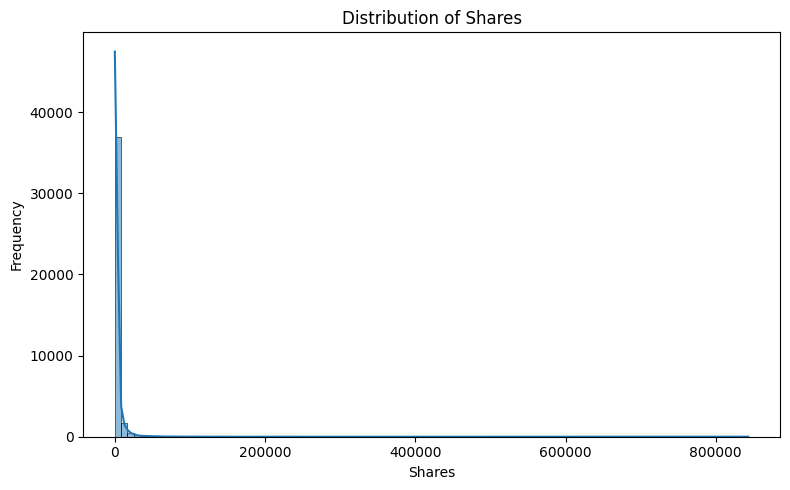

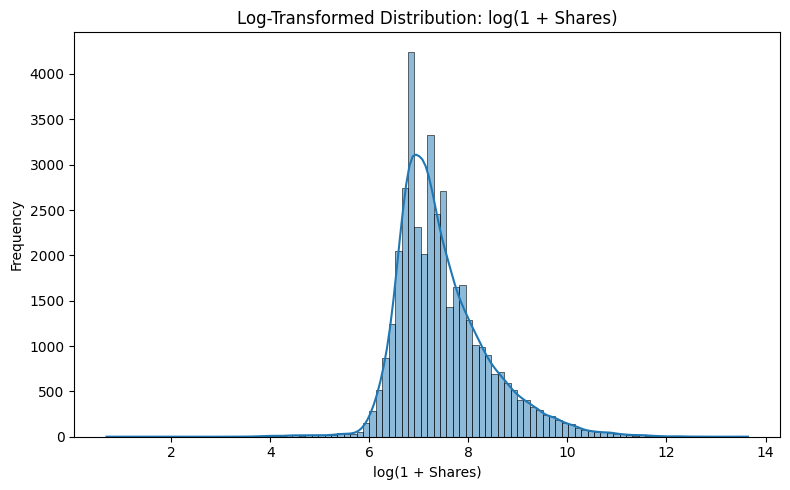

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean column names (UCI file often has leading spaces, e.g., ' shares')
df.columns = df.columns.str.strip()

# Safety check: ensure target exists
assert "shares" in df.columns, "Target column 'shares' not found after stripping column names."


plt.figure(figsize=(8,5))
sns.histplot(df["shares"], bins=100, kde=True)
plt.title("Distribution of Shares")
plt.xlabel("Shares")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Create log(1+shares) for visualization/modeling convenience
df["log_shares"] = np.log1p(df["shares"])

plt.figure(figsize=(8,5))
sns.histplot(df["log_shares"], bins=100, kde=True)
plt.title("Log-Transformed Distribution: log(1 + Shares)")
plt.xlabel("log(1 + Shares)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


The top histogram shows that the **raw “shares” variable is extremely right-skewed**, with most articles receiving only a few hundred shares while a small number receive hundreds of thousands.

This heavy skew can distort statistical models and violate normality assumptions.

The bottom histogram displays a **log(1 + shares) transformation**, which compresses extreme values and spreads out the lower range.

After transformation, the distribution is much closer to **bell-shaped and symmetric**, reducing the influence of outliers.

This transformation makes the response variable more suitable for **linear regression and correlation analyses**.


## **2.3 Univariate Analysis.**



### **1. timedelta**

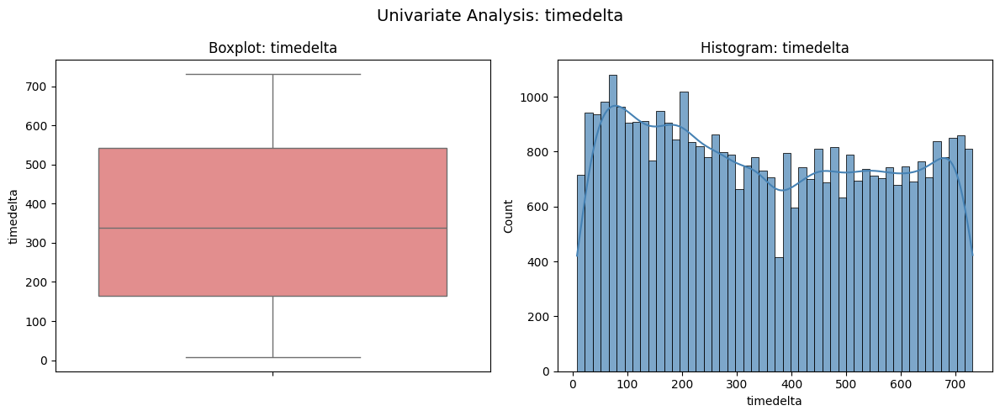

In [106]:
plt.figure(figsize=(12,5))

# Boxplot
plt.subplot(1,2,1)
sns.boxplot(y=df["timedelta"], color="lightcoral")
plt.title("Boxplot: timedelta")

# Histogram
plt.subplot(1,2,2)
sns.histplot(df["timedelta"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: timedelta")
plt.xlabel("timedelta")

plt.suptitle("Univariate Analysis: timedelta", fontsize=14)
plt.tight_layout()
plt.show()


The distribution of timedelta values is almost uniform, spread fairly evenly across the range 0–700.

The boxplot shows that the middle 50% of values lie between ~200 and ~550, with no extreme outliers.

 This indicates steady coverage across time without strong clustering.

### **2. n_tokens_title**

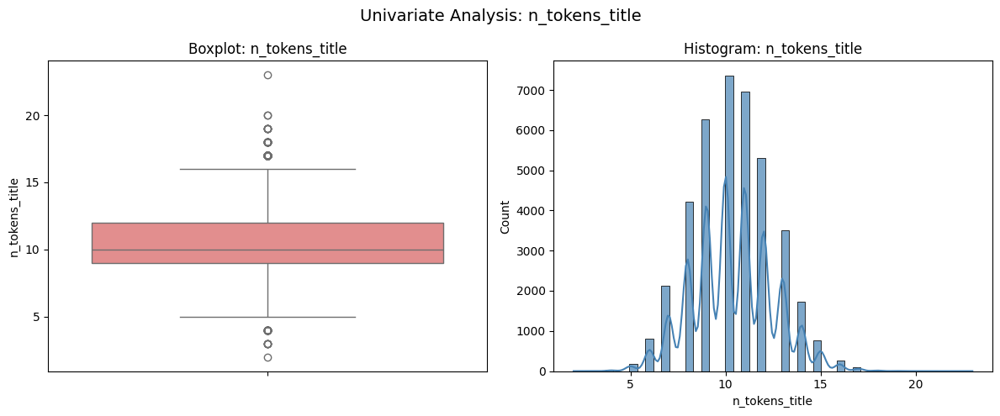

In [107]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["n_tokens_title"], color="lightcoral")
plt.title("Boxplot: n_tokens_title")

plt.subplot(1,2,2)
sns.histplot(df["n_tokens_title"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: n_tokens_title")
plt.xlabel("n_tokens_title")

plt.suptitle("Univariate Analysis: n_tokens_title", fontsize=14)
plt.tight_layout()
plt.show()


Most titles contain between 8–12 tokens, forming a near-normal distribution.

 The boxplot shows a compact spread with a few outliers on both the lower (short titles) and higher (long titles) ends.

  This suggests titles are generally consistent in length, with rare exceptions.

### **3. n_tokens_content**

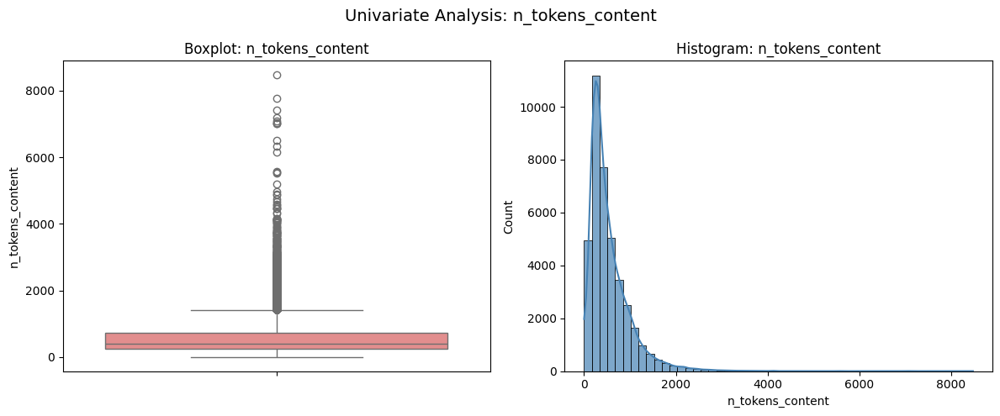

In [108]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["n_tokens_content"], color="lightcoral")
plt.title("Boxplot: n_tokens_content")

plt.subplot(1,2,2)
sns.histplot(df["n_tokens_content"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: n_tokens_content")
plt.xlabel("n_tokens_content")

plt.suptitle("Univariate Analysis: n_tokens_content", fontsize=14)
plt.tight_layout()
plt.show()


The content token counts are highly right-skewed — most documents have fewer than 1000 tokens, while a small number extend up to 8000.

 The boxplot highlights many outliers due to this long tail.

 This suggests that while most documents are concise, a few very lengthy ones dominate the upper range.

### **4. n_unique_tokens**

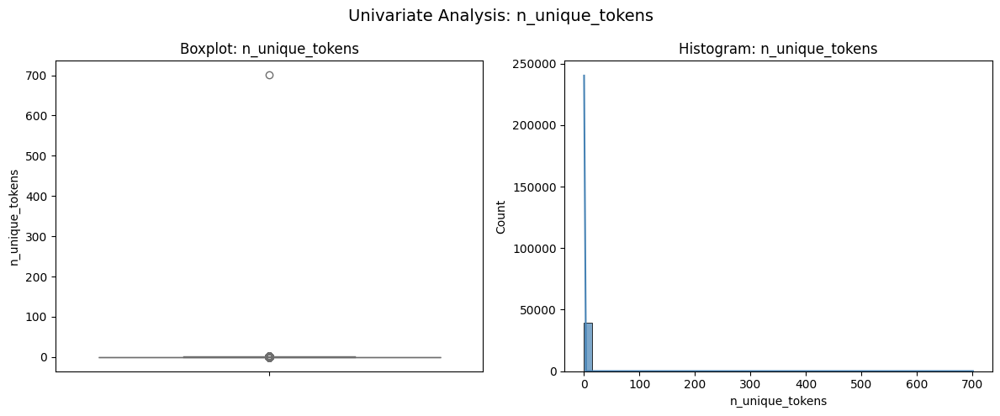

In [109]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["n_unique_tokens"], color="lightcoral")
plt.title("Boxplot: n_unique_tokens")

plt.subplot(1,2,2)
sns.histplot(df["n_unique_tokens"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: n_unique_tokens")
plt.xlabel("n_unique_tokens")

plt.suptitle("Univariate Analysis: n_unique_tokens", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is extremely right-skewed, with most values concentrated near zero.

The boxplot shows almost all observations clustered at the lower end, with a few extreme outliers up to ~700.

This suggests that unique token usage is generally very low.

### **5. n_non_stop_words**

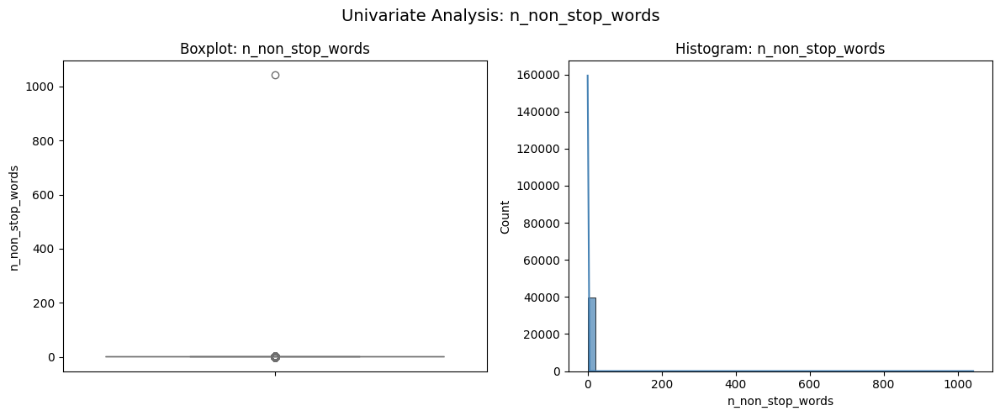

In [110]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["n_non_stop_words"], color="lightcoral")
plt.title("Boxplot: n_non_stop_words")

plt.subplot(1,2,2)
sns.histplot(df["n_non_stop_words"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: n_non_stop_words")
plt.xlabel("n_non_stop_words")

plt.suptitle("Univariate Analysis: n_non_stop_words", fontsize=14)
plt.tight_layout()
plt.show()


Most values are close to zero, with very few cases extending up to ~1000.

 The histogram is heavily skewed, and the boxplot highlights strong outliers.

  This indicates that the majority of text has very few non-stop words.

### **6. n_non_stop_unique_tokens**

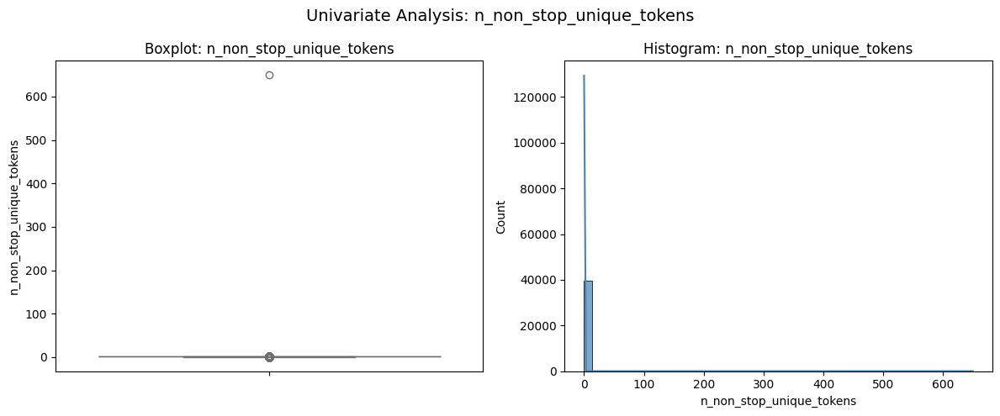

In [111]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["n_non_stop_unique_tokens"], color="lightcoral")
plt.title("Boxplot: n_non_stop_unique_tokens")

plt.subplot(1,2,2)
sns.histplot(df["n_non_stop_unique_tokens"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: n_non_stop_unique_tokens")
plt.xlabel("n_non_stop_unique_tokens")

plt.suptitle("Univariate Analysis: n_non_stop_unique_tokens", fontsize=14)
plt.tight_layout()
plt.show()


Similar to the previous variable, values are mostly near zero, with a long tail reaching ~600.

 The distribution is heavily skewed, and the boxplot again reveals outliers.

 This suggests that most content uses very few unique non-stop words.

### **7. num_hrefs**

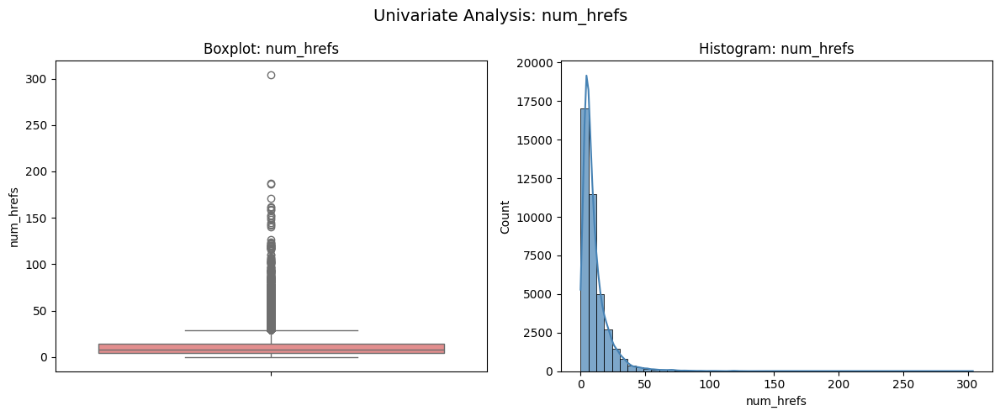

In [112]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["num_hrefs"], color="lightcoral")
plt.title("Boxplot: num_hrefs")

plt.subplot(1,2,2)
sns.histplot(df["num_hrefs"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: num_hrefs")
plt.xlabel("num_hrefs")

plt.suptitle("Univariate Analysis: num_hrefs", fontsize=14)
plt.tight_layout()
plt.show()


The histogram shows a strong right-skew, with most documents containing fewer than 20 hyperlinks.

 The boxplot highlights a number of higher outliers, with a few reaching over 300.

  This indicates that while most texts use few links, some rely heavily on external linking.

### **8. num_self_hrefs**

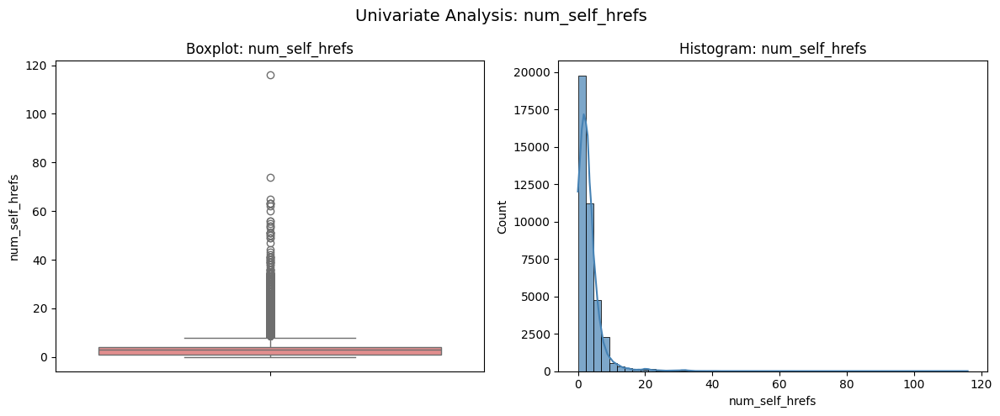

In [113]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["num_self_hrefs"], color="lightcoral")
plt.title("Boxplot: num_self_hrefs")

plt.subplot(1,2,2)
sns.histplot(df["num_self_hrefs"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: num_self_hrefs")
plt.xlabel("num_self_hrefs")

plt.suptitle("Univariate Analysis: num_self_hrefs", fontsize=14)
plt.tight_layout()
plt.show()


The majority of values are concentrated at 0–5, with the histogram showing a sharp drop afterward.

The boxplot highlights many outliers, with some documents containing over 100 self-references.

 This suggests self-linking is rare but excessive in a few cases.

### **9. num_imgs**

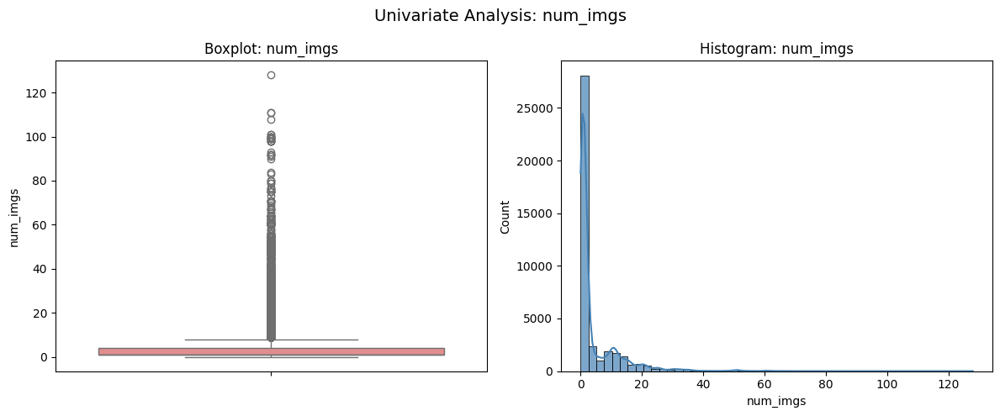

In [114]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["num_imgs"], color="lightcoral")
plt.title("Boxplot: num_imgs")

plt.subplot(1,2,2)
sns.histplot(df["num_imgs"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: num_imgs")
plt.xlabel("num_imgs")

plt.suptitle("Univariate Analysis: num_imgs", fontsize=14)
plt.tight_layout()
plt.show()


The histogram shows a highly right-skewed distribution, with most documents containing fewer than 5 images.

 The boxplot highlights numerous outliers, with some reaching over 100 images.

  This indicates that while images are generally used sparingly, a few documents include a very large number of them.

### **10. num_videos**

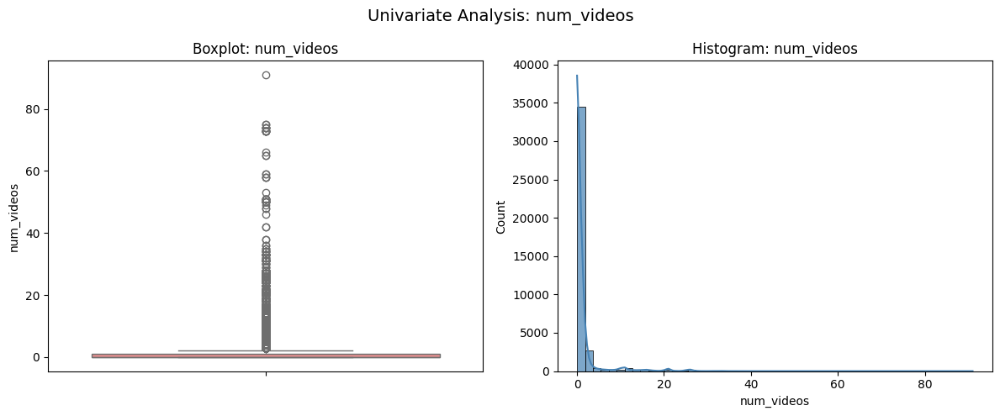

In [115]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["num_videos"], color="lightcoral")
plt.title("Boxplot: num_videos")

plt.subplot(1,2,2)
sns.histplot(df["num_videos"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: num_videos")
plt.xlabel("num_videos")

plt.suptitle("Univariate Analysis: num_videos", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is also right-skewed, with the majority of values concentrated at 0–2 videos.

 The boxplot reveals many outliers, with a few cases containing up to ~80 videos.

 This suggests that video usage is uncommon overall, but certain documents rely heavily on embedded videos.

### **11. average_token_length**

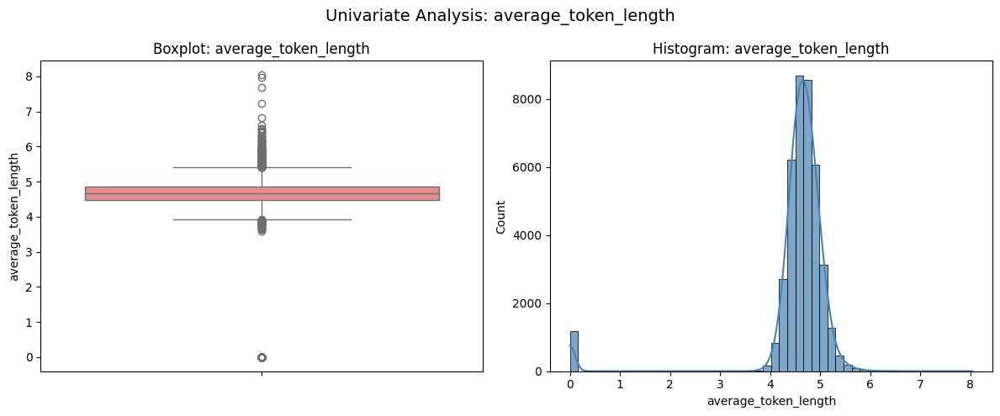

In [116]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["average_token_length"], color="lightcoral")
plt.title("Boxplot: average_token_length")

plt.subplot(1,2,2)
sns.histplot(df["average_token_length"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: average_token_length")
plt.xlabel("average_token_length")

plt.suptitle("Univariate Analysis: average_token_length", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is slightly right-skewed, with most values concentrated between 4–5 tokens.

The boxplot shows a few outliers on the lower side, representing very short articles.

This suggests article length is generally consistent, with occasional very short entries.

### **12. num_keywords**

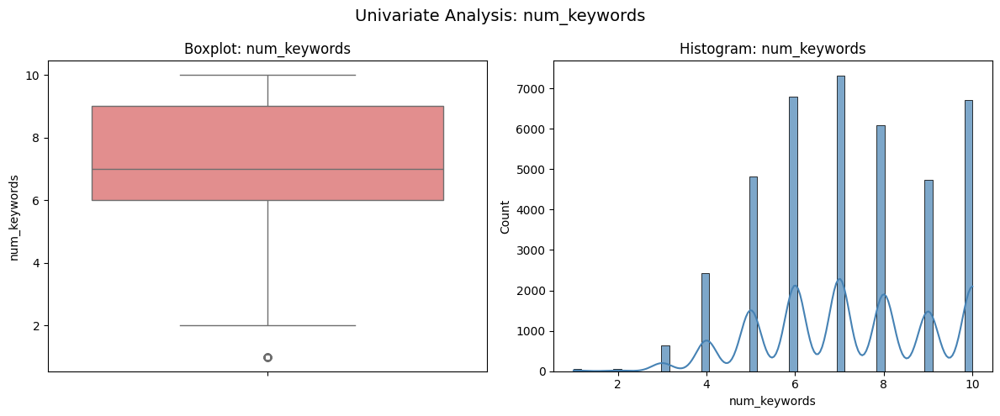

In [117]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["num_keywords"], color="lightcoral")
plt.title("Boxplot: num_keywords")

plt.subplot(1,2,2)
sns.histplot(df["num_keywords"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: num_keywords")
plt.xlabel("num_keywords")

plt.suptitle("Univariate Analysis: num_keywords", fontsize=14)
plt.tight_layout()
plt.show()


The distribution shows peaks at each integer from 1–10, with higher concentration near 5–10 keywords.

The boxplot reveals very few outliers, indicating balanced keyword usage.

This suggests most articles are well-tagged, with a small number having minimal keywords.

### **13. data_channel_is_lifestyle**

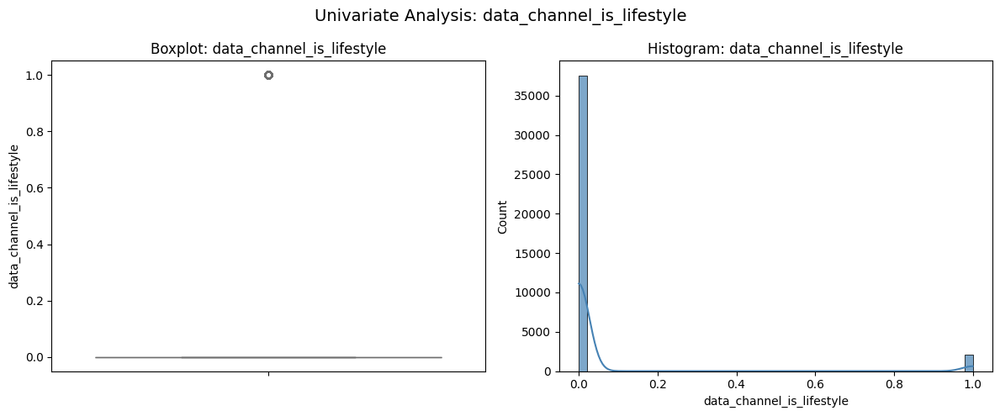

In [118]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["data_channel_is_lifestyle"], color="lightcoral")
plt.title("Boxplot: data_channel_is_lifestyle")

plt.subplot(1,2,2)
sns.histplot(df["data_channel_is_lifestyle"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: data_channel_is_lifestyle")
plt.xlabel("data_channel_is_lifestyle")

plt.suptitle("Univariate Analysis: data_channel_is_lifestyle", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is highly right-skewed, with almost all values at 0 and very few at 1.

The boxplot confirms extreme imbalance, with nearly no articles in the lifestyle category.

This suggests lifestyle content is rare and may contribute little to modeling.

### **14. data_channel_is_entertainment**

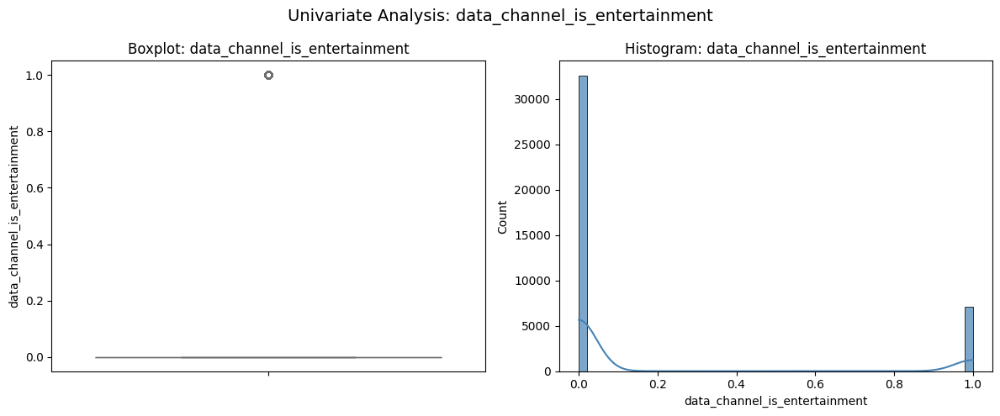

In [119]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["data_channel_is_entertainment"], color="lightcoral")
plt.title("Boxplot: data_channel_is_entertainment")

plt.subplot(1,2,2)
sns.histplot(df["data_channel_is_entertainment"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: data_channel_is_entertainment")
plt.xlabel("data_channel_is_entertainment")

plt.suptitle("Univariate Analysis: data_channel_is_entertainment", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is right-skewed, but has a larger proportion of 1s compared to lifestyle.

The boxplot still shows class imbalance, with most articles not in entertainment.

This suggests entertainment content is present but not dominant in the dataset.

### **15. data_channel_is_bus**

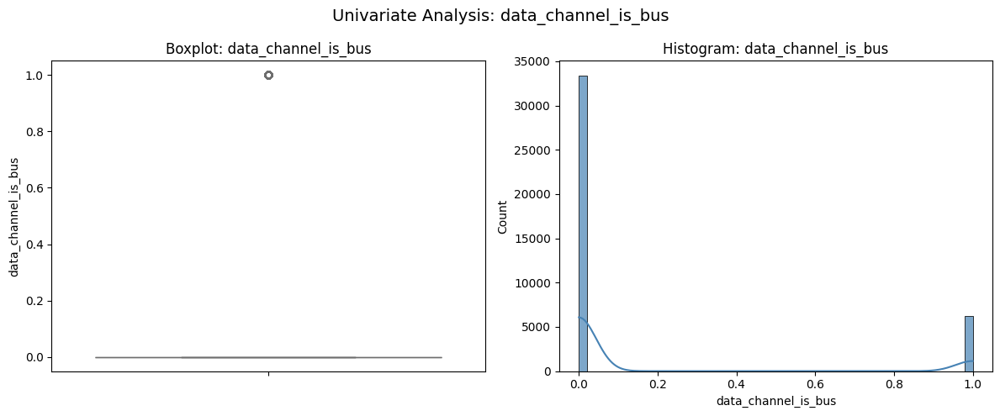

In [120]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["data_channel_is_bus"], color="lightcoral")
plt.title("Boxplot: data_channel_is_bus")

plt.subplot(1,2,2)
sns.histplot(df["data_channel_is_bus"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: data_channel_is_bus")
plt.xlabel("data_channel_is_bus")

plt.suptitle("Univariate Analysis: data_channel_is_bus", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is right-skewed with more 1s than entertainment but still fewer than 0s.

The boxplot shows a moderate imbalance but not extreme.

This suggests business articles are a moderately common category.

### **16. data_channel_is_socmed**

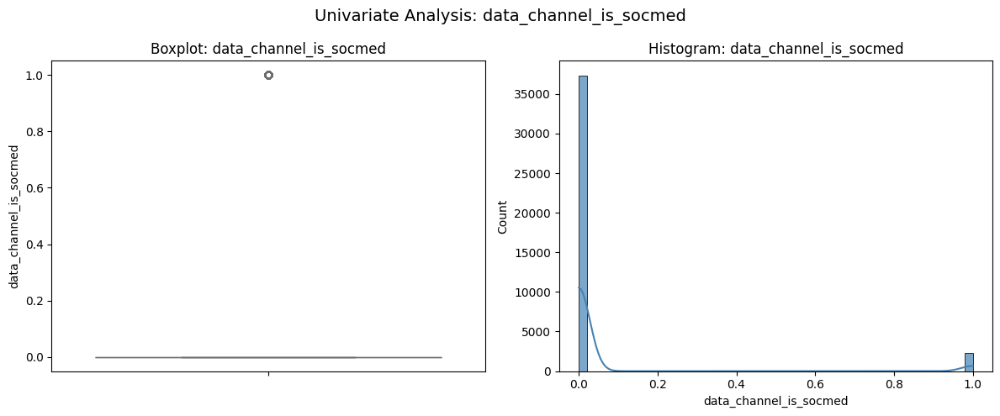

In [121]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["data_channel_is_socmed"], color="lightcoral")
plt.title("Boxplot: data_channel_is_socmed")

plt.subplot(1,2,2)
sns.histplot(df["data_channel_is_socmed"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: data_channel_is_socmed")
plt.xlabel("data_channel_is_socmed")

plt.suptitle("Univariate Analysis: data_channel_is_socmed", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is heavily skewed toward 0, with very few articles having value 1.

The boxplot reflects this imbalance clearly.

This suggests social media articles are rare and might need rebalancing for modeling.

### **17. data_channel_is_tech**

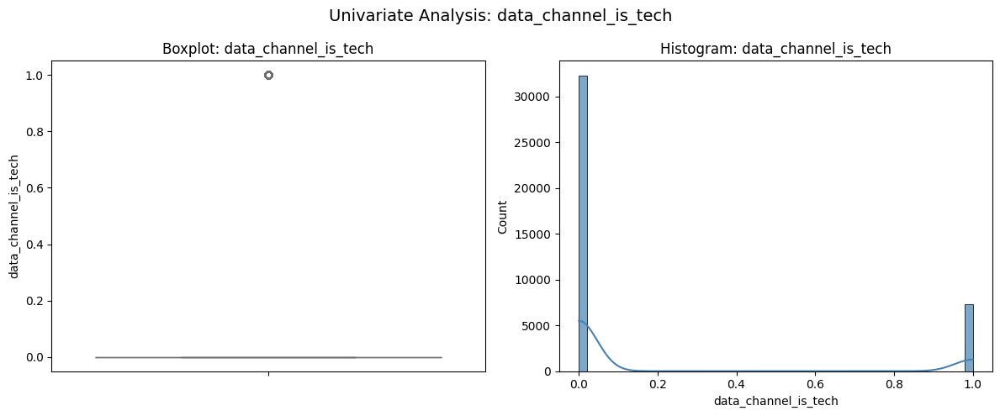

In [122]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["data_channel_is_tech"], color="lightcoral")
plt.title("Boxplot: data_channel_is_tech")

plt.subplot(1,2,2)
sns.histplot(df["data_channel_is_tech"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: data_channel_is_tech")
plt.xlabel("data_channel_is_tech")

plt.suptitle("Univariate Analysis: data_channel_is_tech", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is skewed but shows a noticeable number of 1s compared to other channels.


### **18. data_channel_is_world**

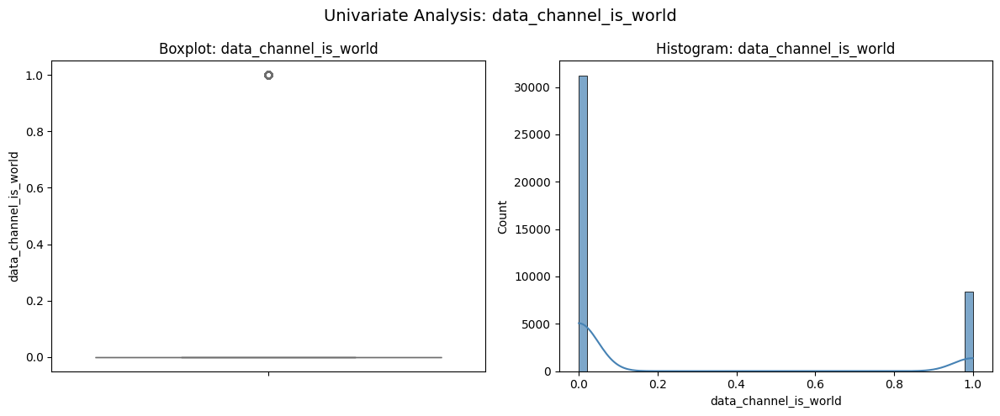

In [123]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["data_channel_is_world"], color="lightcoral")
plt.title("Boxplot: data_channel_is_world")

plt.subplot(1,2,2)
sns.histplot(df["data_channel_is_world"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: data_channel_is_world")
plt.xlabel("data_channel_is_world")

plt.suptitle("Univariate Analysis: data_channel_is_world", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is less skewed, with many articles marked as 1.

### **19. kw_min_min**

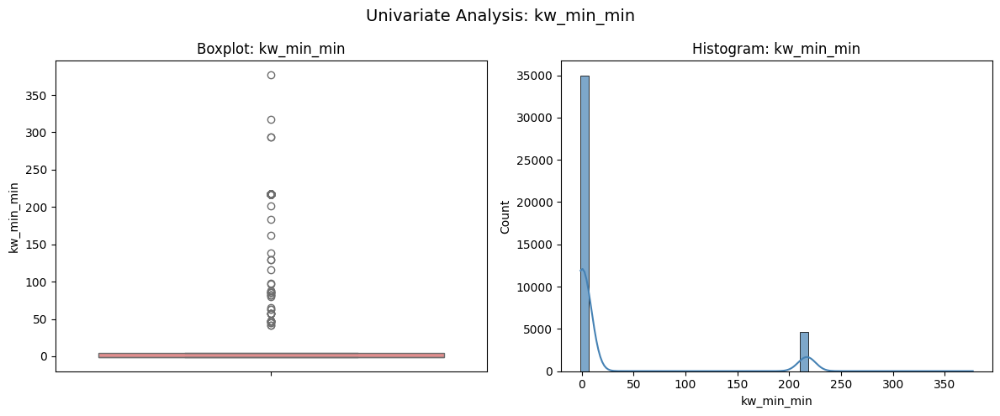

In [124]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["kw_min_min"], color="lightcoral")
plt.title("Boxplot: kw_min_min")

plt.subplot(1,2,2)
sns.histplot(df["kw_min_min"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: kw_min_min")
plt.xlabel("kw_min_min")

plt.suptitle("Univariate Analysis: kw_min_min", fontsize=14)
plt.tight_layout()
plt.show()


### **20. kw_max_min**

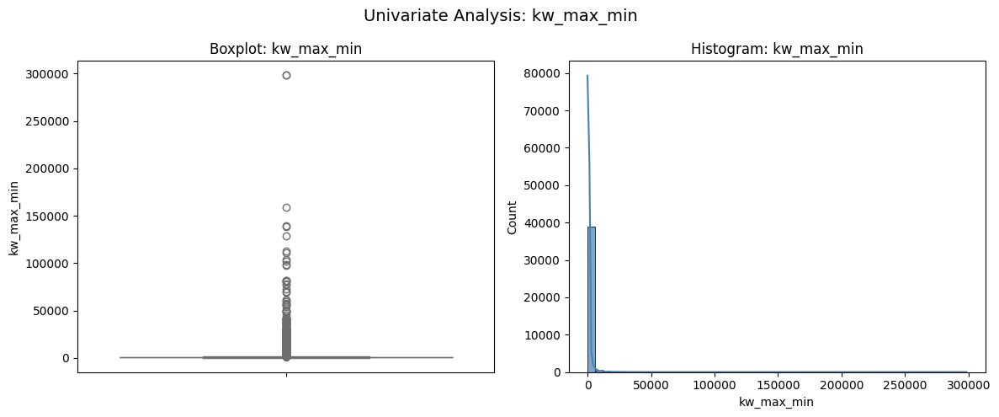

In [125]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["kw_max_min"], color="lightcoral")
plt.title("Boxplot: kw_max_min")

plt.subplot(1,2,2)
sns.histplot(df["kw_max_min"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: kw_max_min")
plt.xlabel("kw_max_min")

plt.suptitle("Univariate Analysis: kw_max_min", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is right-skewed, heavily concentrated at the lower end.

Boxplot shows outliers reaching up to ~300,000.

This implies most articles have low minimum keyword max values, with rare cases showing very high keyword importance.

### **21. kw_avg_min**

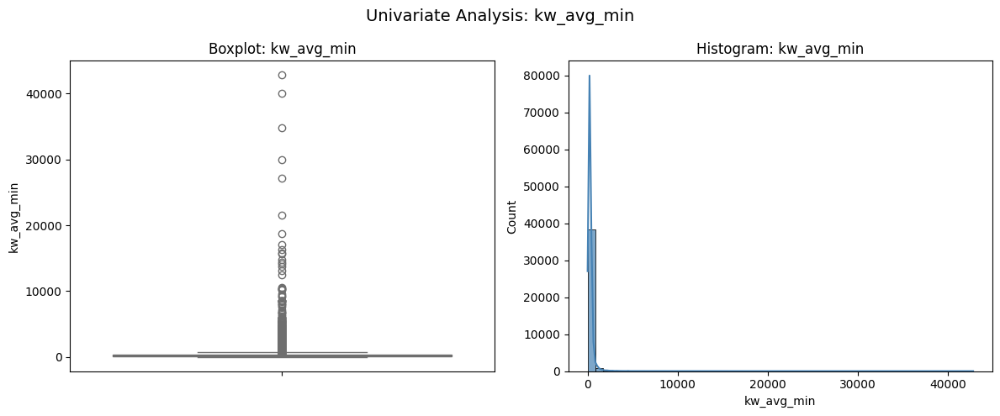

In [126]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["kw_avg_min"], color="lightcoral")
plt.title("Boxplot: kw_avg_min")

plt.subplot(1,2,2)
sns.histplot(df["kw_avg_min"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: kw_avg_min")
plt.xlabel("kw_avg_min")

plt.suptitle("Univariate Analysis: kw_avg_min", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is highly right-skewed, with most values close to zero.

Boxplot shows many extreme outliers reaching very high values (~40,000).

This suggests that for most articles, the average minimum keyword share is very low, with a few exceptions having very high values.

### **22. kw_min_max**

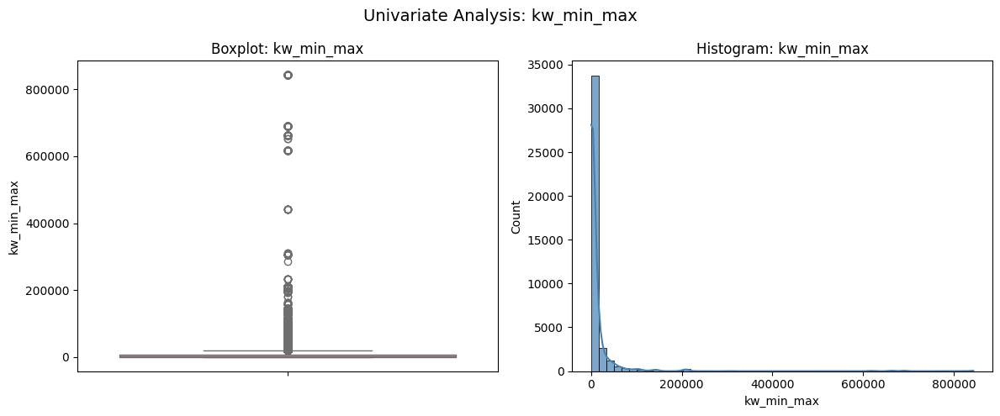

In [127]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["kw_min_max"], color="lightcoral")
plt.title("Boxplot: kw_min_max")

plt.subplot(1,2,2)
sns.histplot(df["kw_min_max"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: kw_min_max")
plt.xlabel("kw_min_max")

plt.suptitle("Univariate Analysis: kw_min_max", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is extremely right-skewed, with the majority near zero.

Several extreme outliers exist, going up to ~800,000.

This indicates that maximum minimum keyword shares are usually very small, but a few articles have disproportionately high scores.

### **23. kw_max_max**

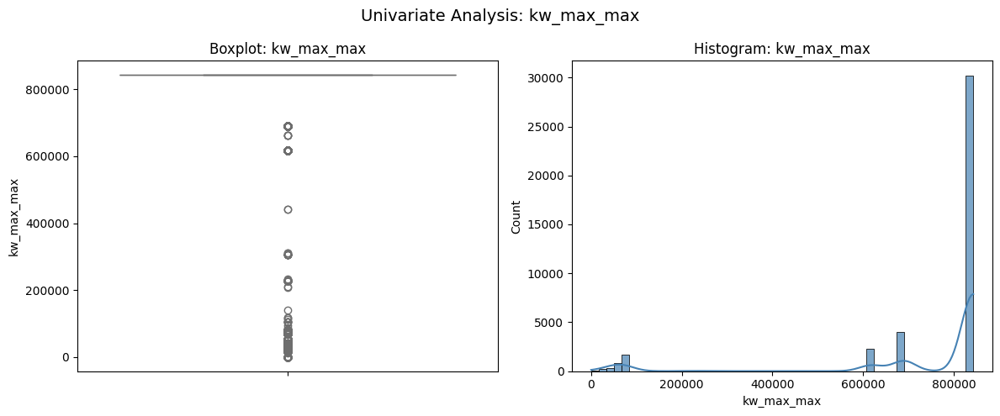

In [128]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["kw_max_max"], color="lightcoral")
plt.title("Boxplot: kw_max_max")

plt.subplot(1,2,2)
sns.histplot(df["kw_max_max"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: kw_max_max")
plt.xlabel("kw_max_max")

plt.suptitle("Univariate Analysis: kw_max_max", fontsize=14)
plt.tight_layout()
plt.show()


The distribution shows a spike near very high values, forming a right-skewed pattern.

Boxplot reveals many outliers, with some reaching above 800,000.

This suggests that some keywords dominate strongly in certain articles, while most have lower maximum shares.

### **24. kw_avg_max**

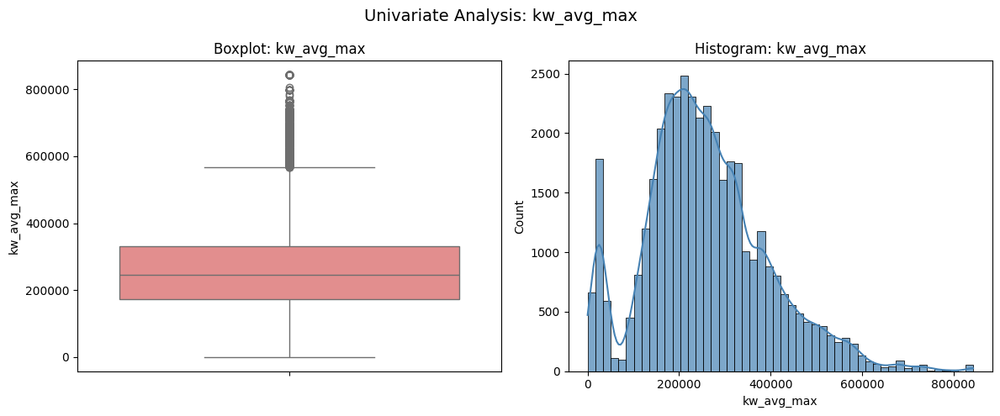

In [129]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["kw_avg_max"], color="lightcoral")
plt.title("Boxplot: kw_avg_max")

plt.subplot(1,2,2)
sns.histplot(df["kw_avg_max"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: kw_avg_max")
plt.xlabel("kw_avg_max")

plt.suptitle("Univariate Analysis: kw_avg_max", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is slightly right-skewed but more spread out compared to others.

Boxplot shows moderate outliers, with values ranging widely (up to ~800,000).

This indicates average maximum keyword shares are relatively high and varied across articles.

### **25. kw_min_avg**

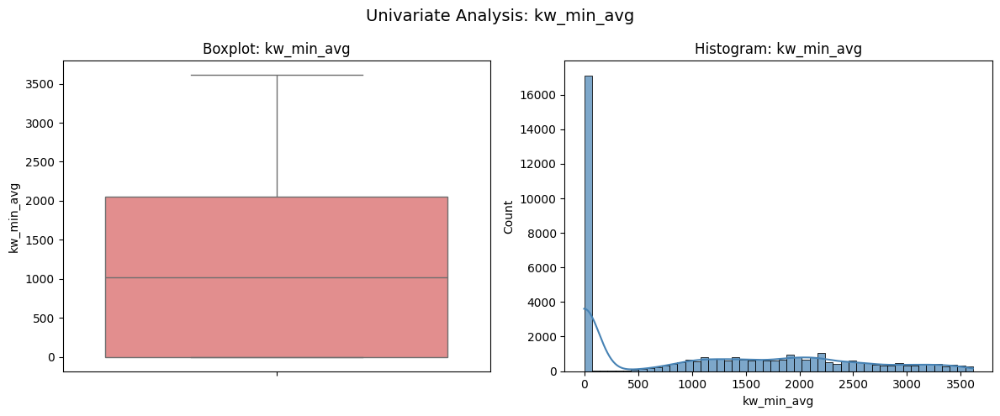

In [130]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["kw_min_avg"], color="lightcoral")
plt.title("Boxplot: kw_min_avg")

plt.subplot(1,2,2)
sns.histplot(df["kw_min_avg"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: kw_min_avg")
plt.xlabel("kw_min_avg")

plt.suptitle("Univariate Analysis: kw_min_avg", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is heavily right-skewed, clustered near zero.

Boxplot indicates minimal outliers, showing that minimum average keyword shares are generally very small.

This suggests keywords with low engagement remain consistently low across articles.

### **26. kw_max_avg**

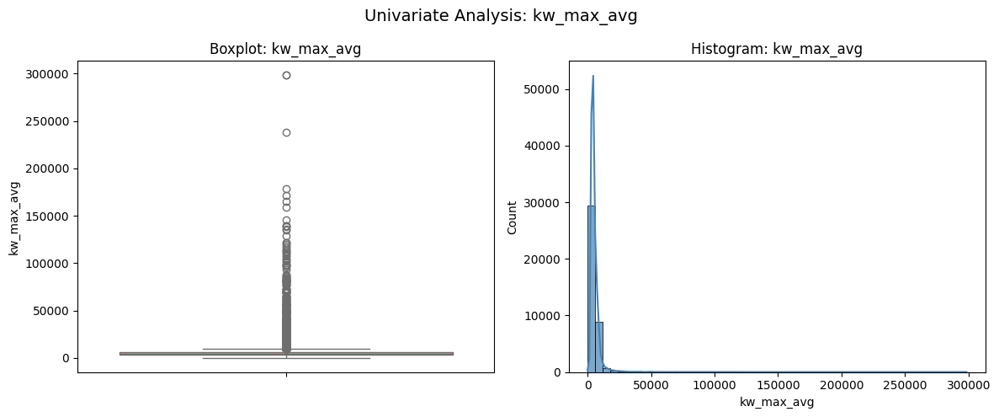

In [131]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["kw_max_avg"], color="lightcoral")
plt.title("Boxplot: kw_max_avg")

plt.subplot(1,2,2)
sns.histplot(df["kw_max_avg"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: kw_max_avg")
plt.xlabel("kw_max_avg")

plt.suptitle("Univariate Analysis: kw_max_avg", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is very right-skewed, with most values near zero.

Boxplot reveals a few extreme outliers (above 250,000).

This means most articles have low average keyword importance, with rare cases having very strong keyword relevance.

### **27. kw_avg_avg**

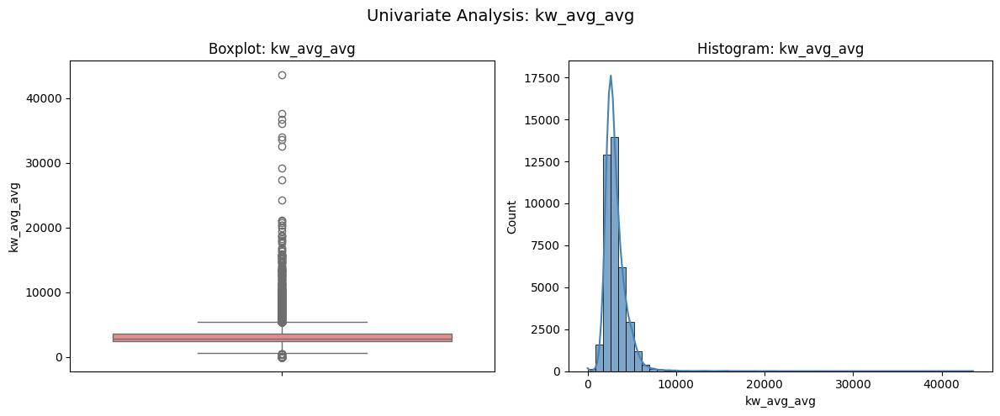

In [132]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["kw_avg_avg"], color="lightcoral")
plt.title("Boxplot: kw_avg_avg")

plt.subplot(1,2,2)
sns.histplot(df["kw_avg_avg"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: kw_avg_avg")
plt.xlabel("kw_avg_avg")

plt.suptitle("Univariate Analysis: kw_avg_avg", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is moderately right-skewed, with most values below ~10,000.

Boxplot shows some outliers, but the majority are concentrated at lower values.

This suggests average keyword shares are relatively small and stable across articles.

### **28. self_reference_min_shares**

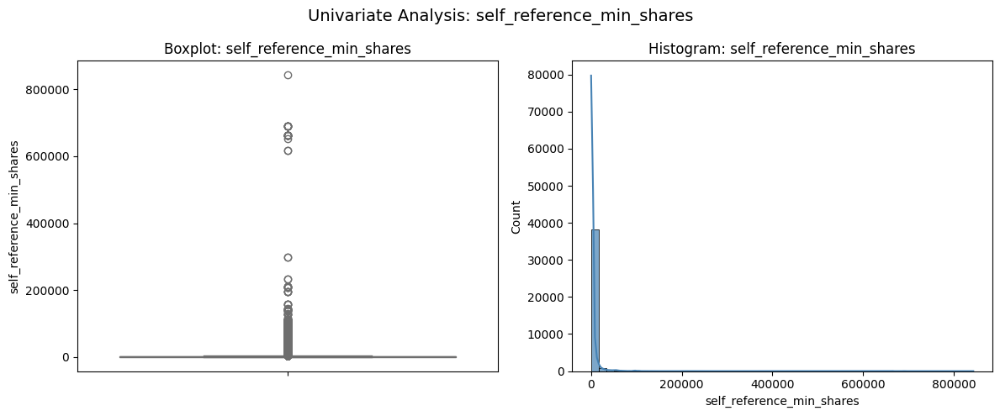

In [133]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["self_reference_min_shares"], color="lightcoral")
plt.title("Boxplot: self_reference_min_shares")

plt.subplot(1,2,2)
sns.histplot(df["self_reference_min_shares"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: self_reference_min_shares")
plt.xlabel("self_reference_min_shares")

plt.suptitle("Univariate Analysis: self_reference_min_shares", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is extremely right-skewed, concentrated at very low values.

Boxplot shows many extreme outliers up to ~800,000.

This indicates that most articles have very few self-referenced shares, but some are heavily shared, creating long tails.

### **29.  self_reference_max_shares**

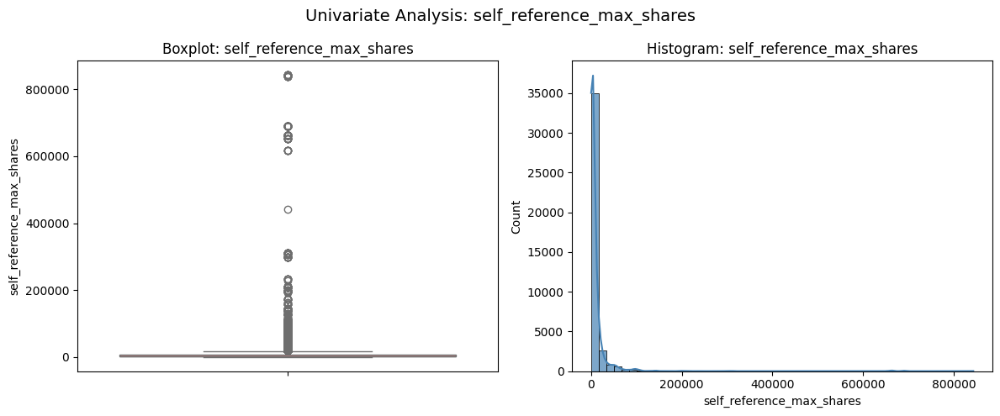

In [134]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["self_reference_max_shares"], color="lightcoral")
plt.title("Boxplot: self_reference_max_shares")

plt.subplot(1,2,2)
sns.histplot(df["self_reference_max_shares"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: self_reference_max_shares")
plt.xlabel("self_reference_max_shares")

plt.suptitle("Univariate Analysis: self_reference_max_shares", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is extremely right-skewed, with most values near zero.

Boxplot shows many extreme outliers reaching up to ~800,000 shares.

This indicates that most articles receive very few self-referenced shares, while a handful go viral.

### **30. self_reference_avg_sharess**

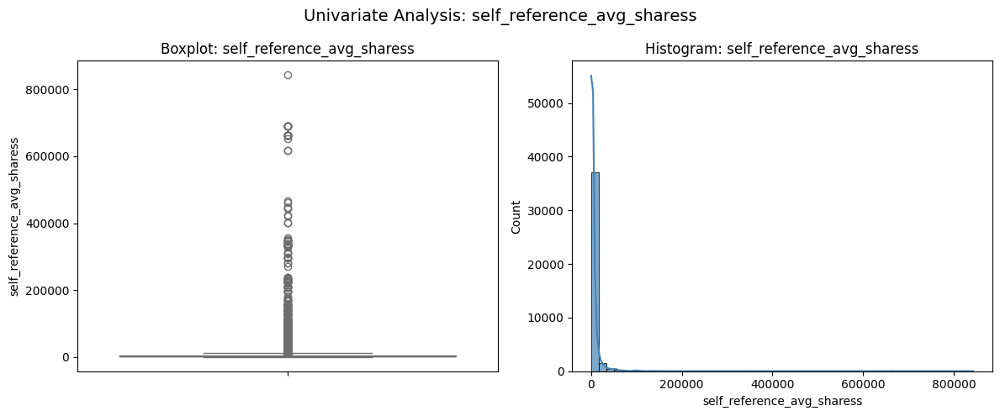

In [135]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["self_reference_avg_sharess"], color="lightcoral")
plt.title("Boxplot: self_reference_avg_sharess")

plt.subplot(1,2,2)
sns.histplot(df["self_reference_avg_sharess"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: self_reference_avg_sharess")
plt.xlabel("self_reference_avg_sharess")

plt.suptitle("Univariate Analysis: self_reference_avg_sharess", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is heavily right-skewed, with most observations concentrated near zero.

Boxplot reveals a long tail of outliers, similar to max shares but with smaller spread.

This suggests average self-reference shares are low overall, with occasional spikes for popular content.

### **31. weekday_is_monday**

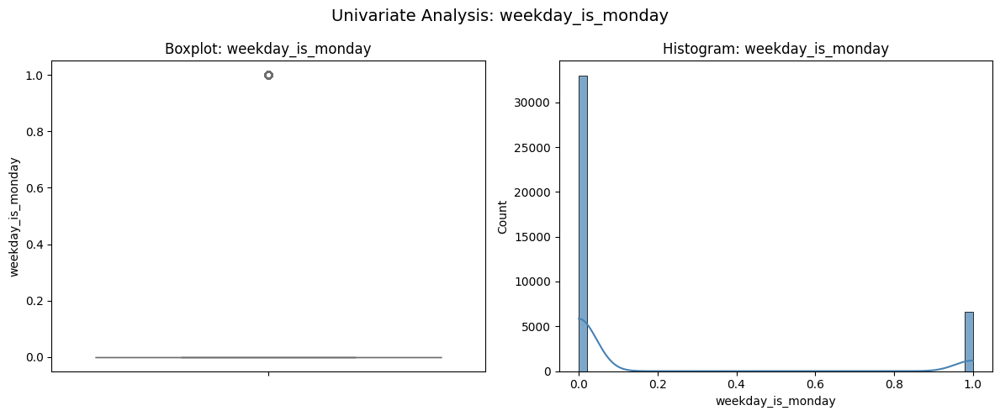

In [136]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["weekday_is_monday"], color="lightcoral")
plt.title("Boxplot: weekday_is_monday")

plt.subplot(1,2,2)
sns.histplot(df["weekday_is_monday"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: weekday_is_monday")
plt.xlabel("weekday_is_monday")

plt.suptitle("Univariate Analysis: weekday_is_monday", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is binary, with most values at 0 and fewer at 1.

Boxplot shows class imbalance but with a fair number of Monday articles present.

This indicates that Monday publication is common enough to be a relevant feature.

### **32. weekday_is_tuesday**

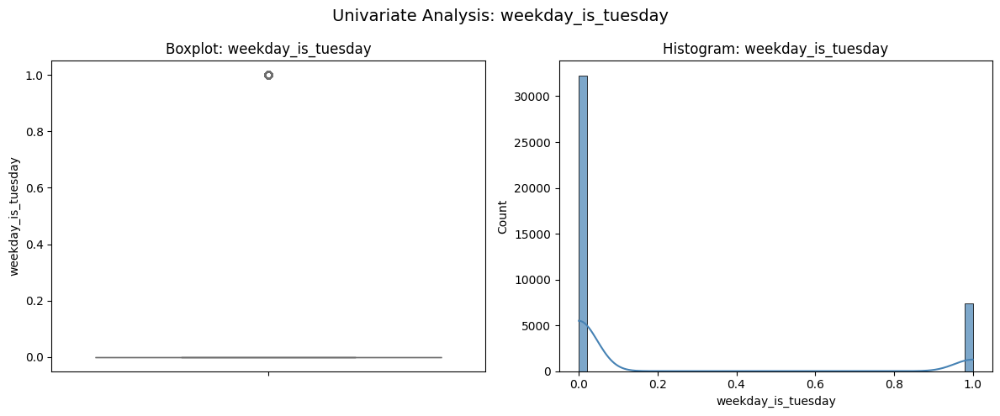

In [137]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["weekday_is_tuesday"], color="lightcoral")
plt.title("Boxplot: weekday_is_tuesday")
plt.subplot(1,2,2)
sns.histplot(df["weekday_is_tuesday"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: weekday_is_tuesday")
plt.xlabel("weekday_is_tuesday")
plt.suptitle("Univariate Analysis: weekday_is_tuesday", fontsize=14)
plt.tight_layout()
plt.show()


Binary distribution, mostly 0s with fewer 1s.

Boxplot shows similar pattern to Monday, with moderate representation.

This suggests Tuesday articles follow a comparable publication frequency.

### **33. weekday_is_wednesday**

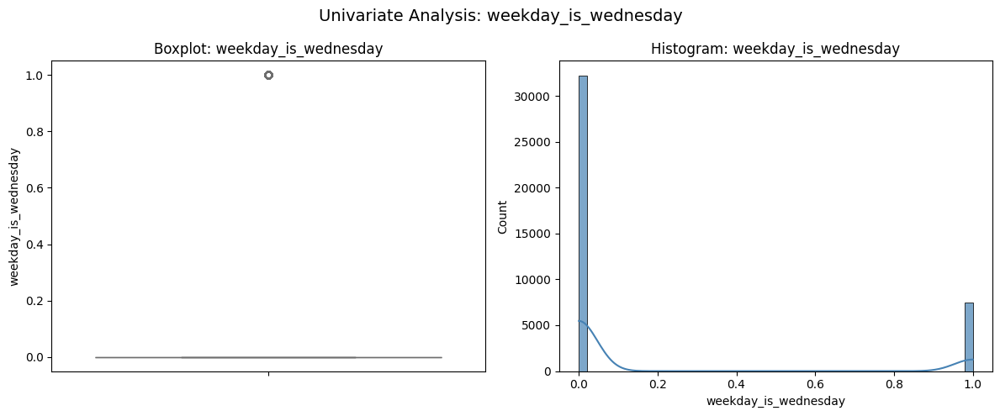

In [138]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["weekday_is_wednesday"], color="lightcoral")
plt.title("Boxplot: weekday_is_wednesday")
plt.subplot(1,2,2)
sns.histplot(df["weekday_is_wednesday"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: weekday_is_wednesday")
plt.xlabel("weekday_is_wednesday")
plt.suptitle("Univariate Analysis: weekday_is_wednesday", fontsize=14)
plt.tight_layout()
plt.show()


Binary distribution, slightly fewer 1s compared to Monday and Tuesday.

Boxplot indicates imbalance but with reasonable data for analysis.

This shows Wednesday publications are slightly lower but still meaningful.

### **34. weekday_is_thursday**

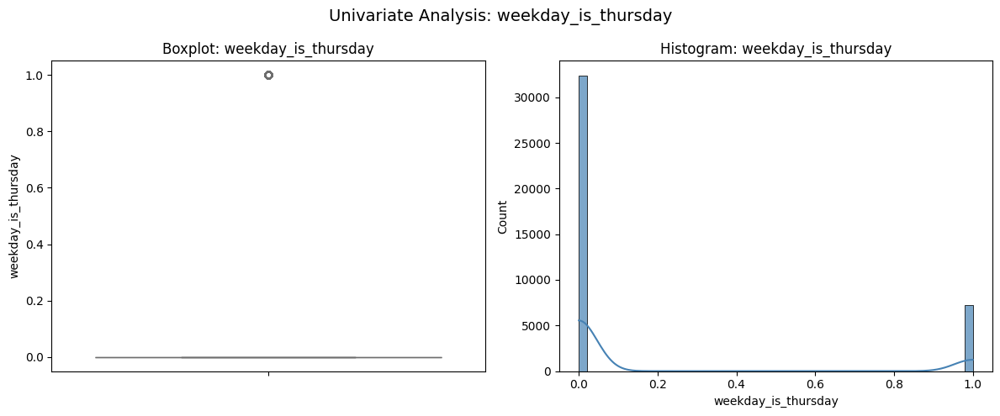

In [139]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["weekday_is_thursday"], color="lightcoral")
plt.title("Boxplot: weekday_is_thursday")
plt.subplot(1,2,2)
sns.histplot(df["weekday_is_thursday"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: weekday_is_thursday")
plt.xlabel("weekday_is_thursday")
plt.suptitle("Univariate Analysis: weekday_is_thursday", fontsize=14)
plt.tight_layout()
plt.show()


Binary feature, mostly 0s with some 1s.

Boxplot indicates moderate but not dominant Thursday activity.

This suggests Thursday has fewer published articles compared to early weekdays.

### **35. weekday_is_friday**

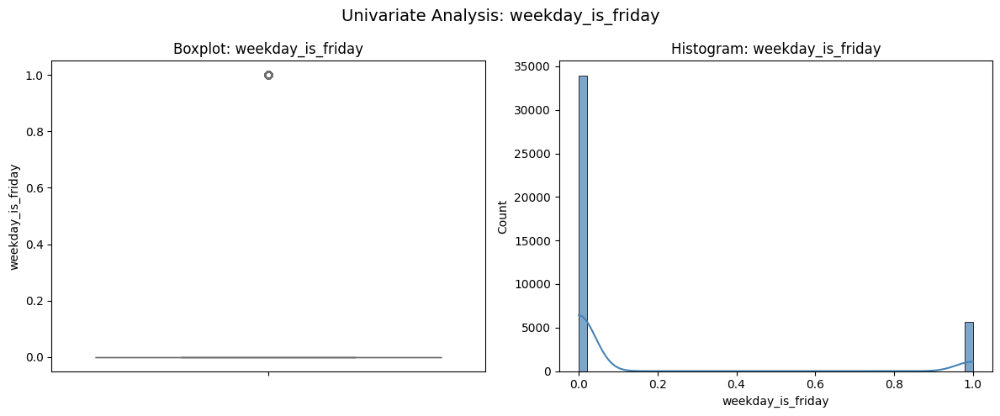

In [140]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["weekday_is_friday"], color="lightcoral")
plt.title("Boxplot: weekday_is_friday")
plt.subplot(1,2,2)
sns.histplot(df["weekday_is_friday"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: weekday_is_friday")
plt.xlabel("weekday_is_friday")
plt.suptitle("Univariate Analysis: weekday_is_friday", fontsize=14)
plt.tight_layout()
plt.show()


Binary distribution with relatively fewer 1s than Monday–Thursday.

Boxplot shows clear skewness, reflecting limited Friday publications.

This may capture end-of-week publishing trends.

### **36. weekday_is_saturday**

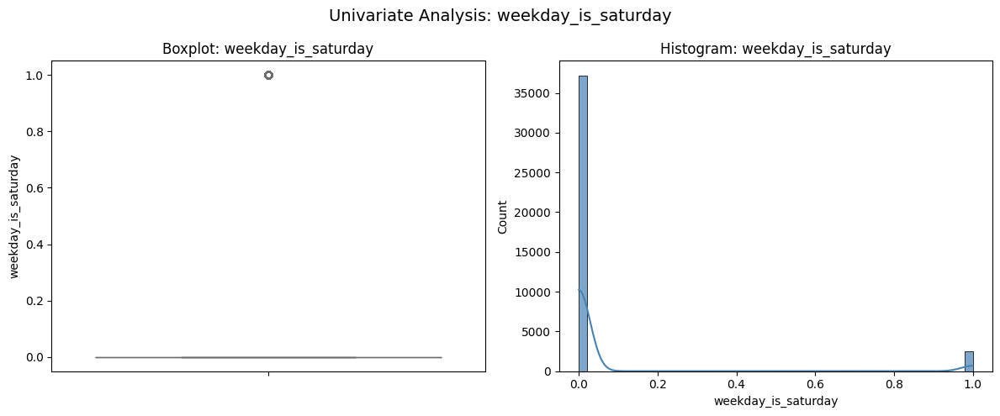

In [141]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["weekday_is_saturday"], color="lightcoral")
plt.title("Boxplot: weekday_is_saturday")
plt.subplot(1,2,2)
sns.histplot(df["weekday_is_saturday"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: weekday_is_saturday")
plt.xlabel("weekday_is_saturday")
plt.suptitle("Univariate Analysis: weekday_is_saturday", fontsize=14)
plt.tight_layout()
plt.show()


Binary variable with very few 1s, mostly 0s.

Boxplot confirms extreme imbalance, meaning Saturday articles are rare.

This suggests minimal weekend activity and low contribution from Saturday posts.

### **37. weekday_is_sunday**

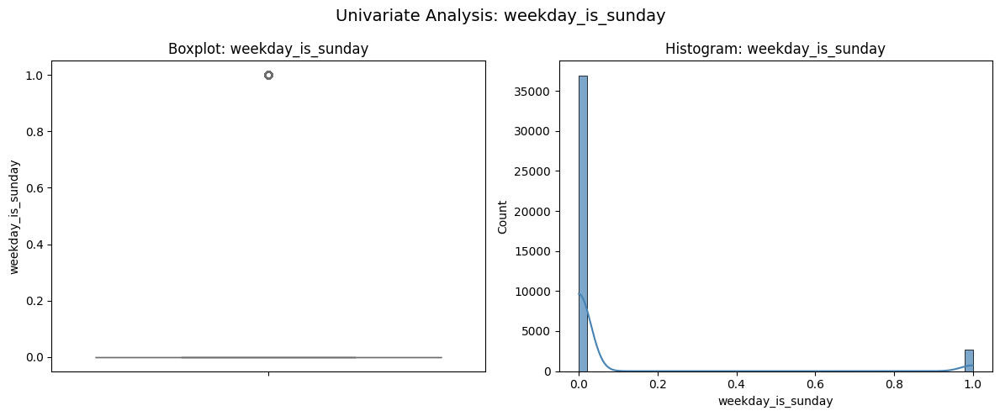

In [142]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["weekday_is_sunday"], color="lightcoral")
plt.title("Boxplot: weekday_is_sunday")
plt.subplot(1,2,2)
sns.histplot(df["weekday_is_sunday"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: weekday_is_sunday")
plt.xlabel("weekday_is_sunday")
plt.suptitle("Univariate Analysis: weekday_is_sunday", fontsize=14)
plt.tight_layout()
plt.show()


Similar to Saturday, distribution is dominated by 0s.

This indicates Sunday has the lowest article activity across the week.

### **38. is_weekend**

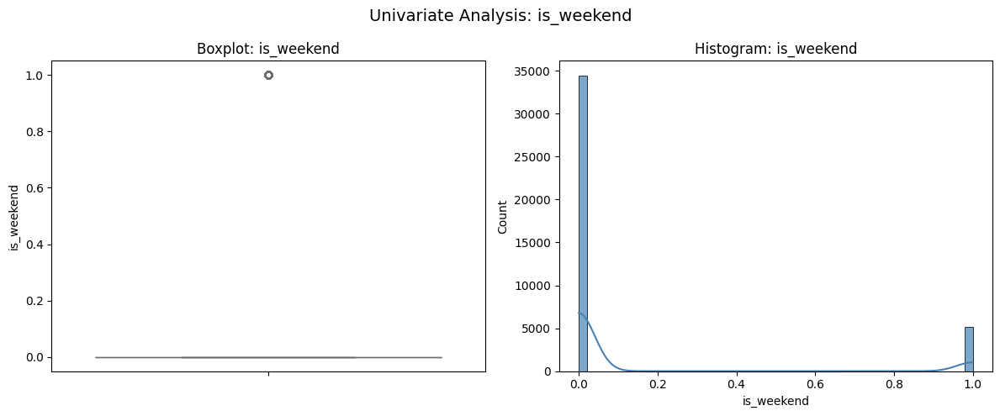

In [143]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["is_weekend"], color="lightcoral")
plt.title("Boxplot: is_weekend")
plt.subplot(1,2,2)
sns.histplot(df["is_weekend"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: is_weekend")
plt.xlabel("is_weekend")
plt.suptitle("Univariate Analysis: is_weekend", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is highly imbalanced, with a dominant peak at 0 (weekdays) and a small spike at 1 (weekends).

Boxplot shows a binary distribution with almost all values at 0, and very few at 1.

No data quality issues, but the variable is heavily skewed toward weekdays.

### **39. LDA_00**

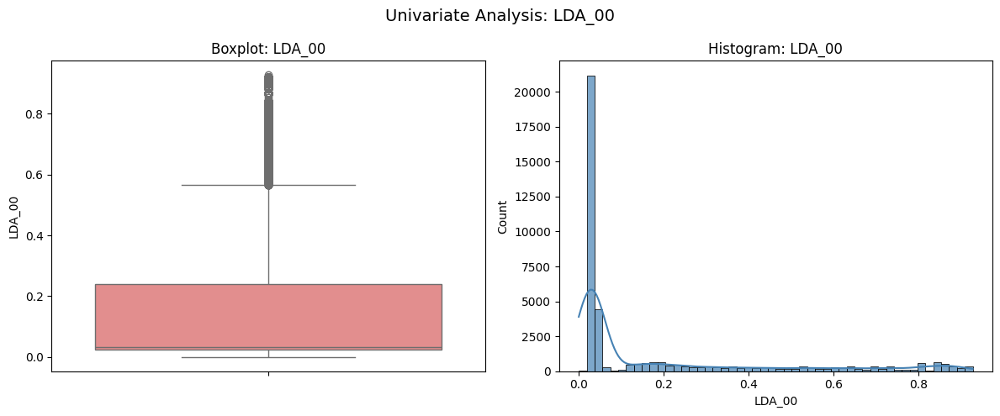

In [144]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["LDA_00"], color="lightcoral")
plt.title("Boxplot: LDA_00")
plt.subplot(1,2,2)
sns.histplot(df["LDA_00"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: LDA_00")
plt.xlabel("LDA_00")
plt.suptitle("Univariate Analysis: LDA_00", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is right-skewed, with most values concentrated near 0 and a long tail extending upward.

Boxplot shows some high-end outliers, but the majority of values lie near the lower end.

No quality issues, but the topic is weakly present in most articles.

### **40 LDA_01**

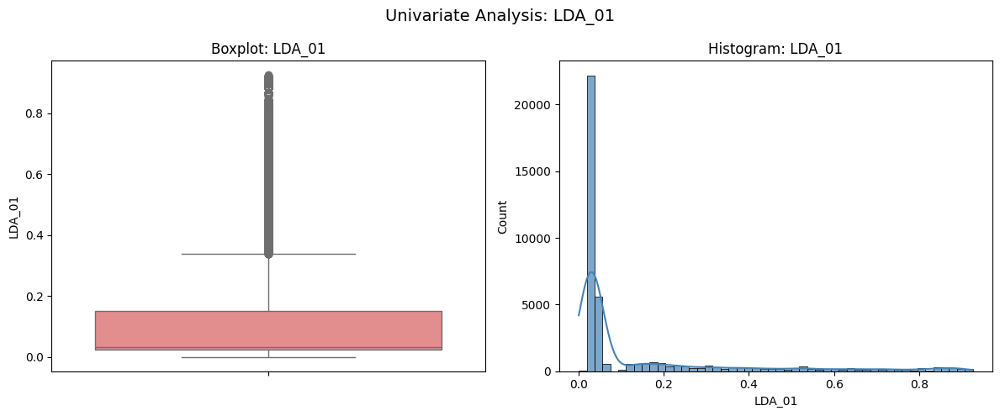

In [145]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["LDA_01"], color="lightcoral")
plt.title("Boxplot: LDA_01")
plt.subplot(1,2,2)
sns.histplot(df["LDA_01"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: LDA_01")
plt.xlabel("LDA_01")
plt.suptitle("Univariate Analysis: LDA_01", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is strongly right-skewed, similar to LDA_00, with a sharp peak near 0.

Boxplot reveals outliers in the upper range, while most values are tightly packed near the baseline.

No major concerns; topic presence is minimal in most articles.

### **41. LDA_02**

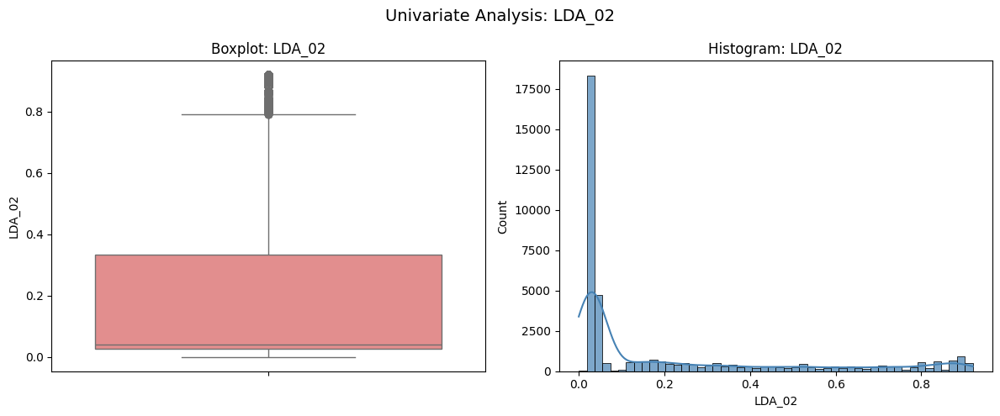

In [146]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["LDA_02"], color="lightcoral")
plt.title("Boxplot: LDA_02")

plt.subplot(1,2,2)
sns.histplot(df["LDA_02"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: LDA_02")
plt.xlabel("LDA_02")

plt.suptitle("Univariate Analysis: LDA_02", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is moderately right-skewed, with a broader spread across mid-values.

Boxplot shows a wider IQR compared to LDA_00 and LDA_01, with a few upper outliers.

Topic appears more frequently, and no significant data issues are observed.

### **42. LDA_03**

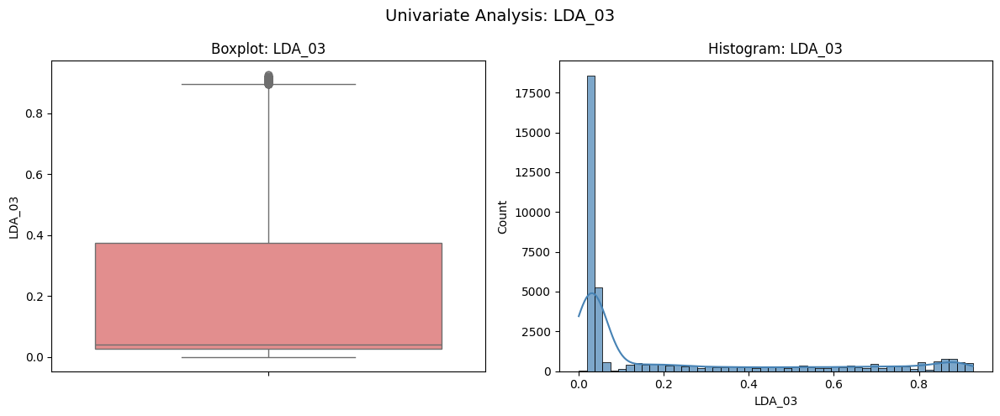

In [147]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["LDA_03"], color="lightcoral")
plt.title("Boxplot: LDA_03")

plt.subplot(1,2,2)
sns.histplot(df["LDA_03"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: LDA_03")
plt.xlabel("LDA_03")

plt.suptitle("Univariate Analysis: LDA_03", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is right-skewed but with more balance across the range, peaking near 0.3.

Boxplot indicates several high-value outliers but a solid spread through the middle range.

This topic is more dominant in the dataset, and the data quality is good.

### **43. LDA_04**

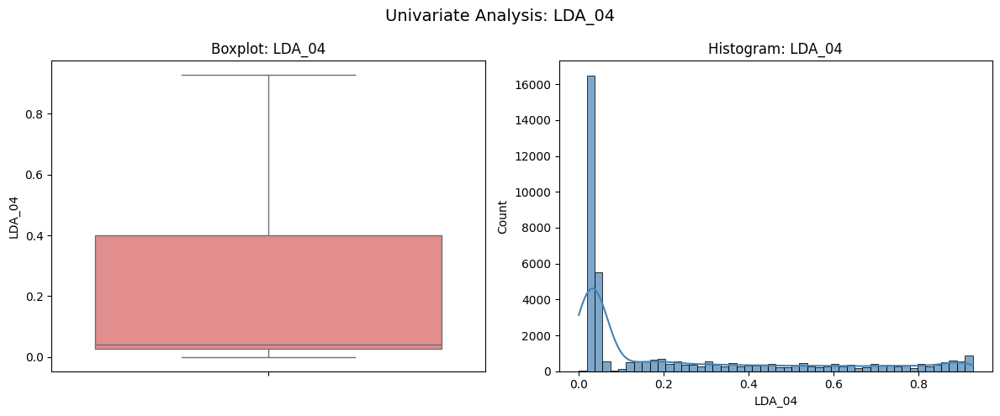

In [148]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["LDA_04"], color="lightcoral")
plt.title("Boxplot: LDA_04")

plt.subplot(1,2,2)
sns.histplot(df["LDA_04"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: LDA_04")
plt.xlabel("LDA_04")

plt.suptitle("Univariate Analysis: LDA_04", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is similar to LDA_03, skewed to the right with values spread across the lower and mid-range.

Boxplot shows a consistent spread with some high-end outliers.

Topic is moderately present across articles; no quality concerns.

### **44. global_subjectivity**

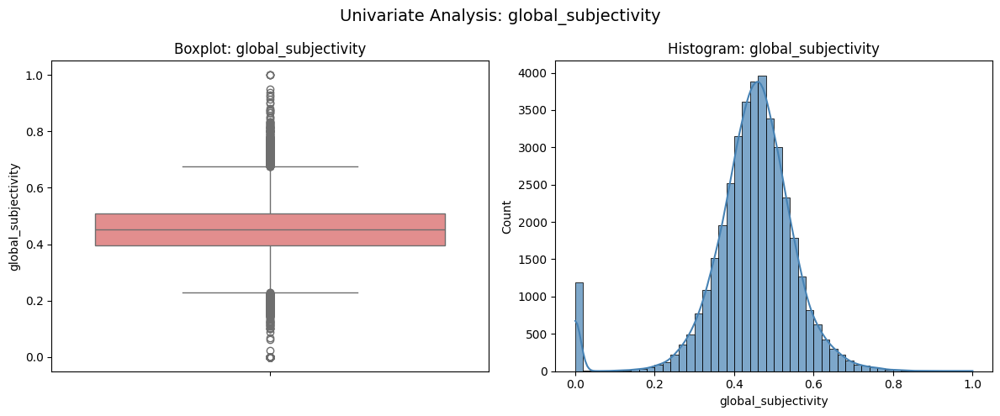

In [149]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["global_subjectivity"], color="lightcoral")
plt.title("Boxplot: global_subjectivity")

plt.subplot(1,2,2)
sns.histplot(df["global_subjectivity"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: global_subjectivity")
plt.xlabel("global_subjectivity")

plt.suptitle("Univariate Analysis: global_subjectivity", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is bell-shaped, slightly right-skewed, centered around 0.45.

Boxplot indicates a few outliers on both ends, but the middle 50% of values is stable.

No data quality issues; articles show a healthy range of subjectivity.

### **45. global_sentiment_polarity**

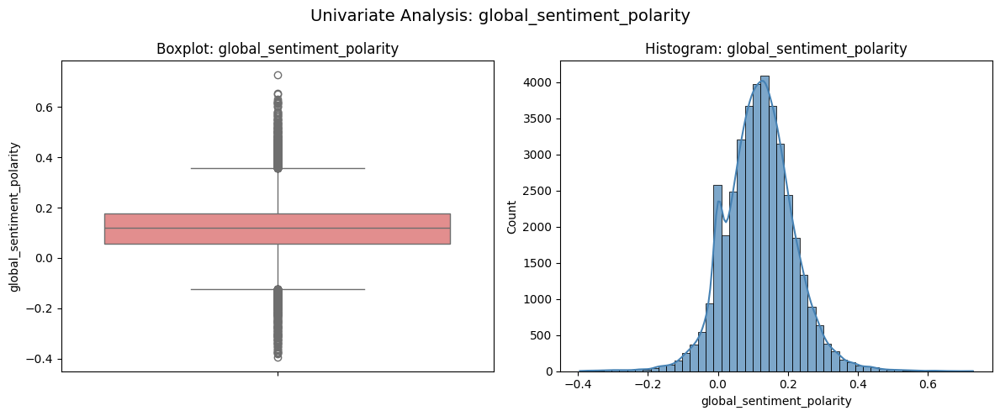

In [150]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["global_sentiment_polarity"], color="lightcoral")
plt.title("Boxplot: global_sentiment_polarity")

plt.subplot(1,2,2)
sns.histplot(df["global_sentiment_polarity"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: global_sentiment_polarity")
plt.xlabel("global_sentiment_polarity")

plt.suptitle("Univariate Analysis: global_sentiment_polarity", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is approximately normal, centered slightly above 0, with a slight positive skew.

Boxplot reveals symmetric spread with a few extreme values on both sides.

Overall sentiment is mildly positive, with no major anomalies or data issues.

### **46. global_rate_positive_words**

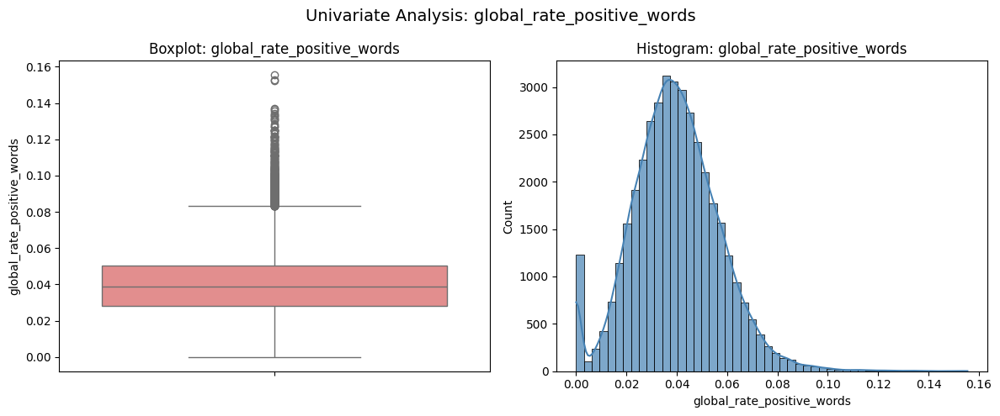

In [151]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["global_rate_positive_words"], color="lightcoral")
plt.title("Boxplot: global_rate_positive_words")

plt.subplot(1,2,2)
sns.histplot(df["global_rate_positive_words"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: global_rate_positive_words")
plt.xlabel("global_rate_positive_words")

plt.suptitle("Univariate Analysis: global_rate_positive_words", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is right-skewed, with most values concentrated around the lower end.

Boxplot shows some high outliers but tight clustering for the majority of values.

Articles generally contain few positive words; skew is expected and not problematic.

### **47. global_rate_negative_words**

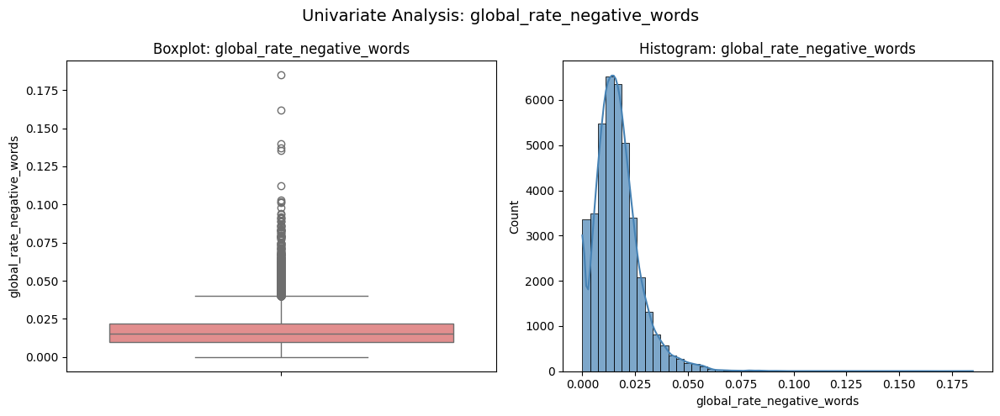

In [152]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["global_rate_negative_words"], color="lightcoral")
plt.title("Boxplot: global_rate_negative_words")

plt.subplot(1,2,2)
sns.histplot(df["global_rate_negative_words"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: global_rate_negative_words")
plt.xlabel("global_rate_negative_words")

plt.suptitle("Univariate Analysis: global_rate_negative_words", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is slightly right-skewed, centered around 4–5 tokens per article.

Boxplot shows some small outliers on the lower end, but most values are tightly packed.

No major data quality issues, just a few very short articles.

### **48. rate_positive_words**

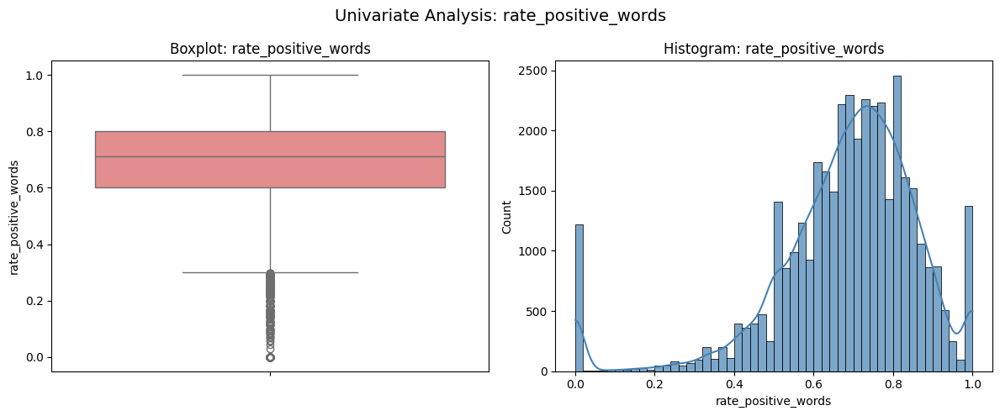

In [153]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["rate_positive_words"], color="lightcoral")
plt.title("Boxplot: rate_positive_words")

plt.subplot(1,2,2)
sns.histplot(df["rate_positive_words"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: rate_positive_words")
plt.xlabel("rate_positive_words")

plt.suptitle("Univariate Analysis: rate_positive_words", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is slightly left-skewed, centered around 0.6.

Boxplot shows a balanced spread with a few lower-end outliers but generally tight packing.

Articles tend to contain a high proportion of positive words, and data quality is consistent.

### **49. rate_negative_words**

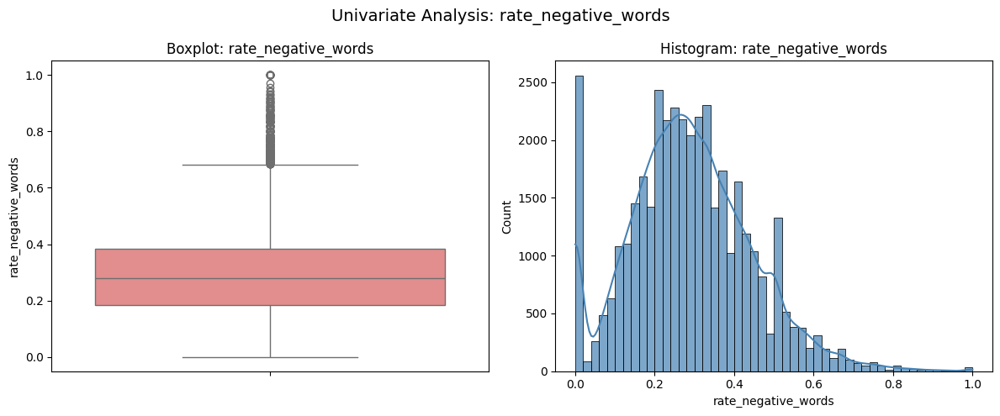

In [154]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["rate_negative_words"], color="lightcoral")
plt.title("Boxplot: rate_negative_words")

plt.subplot(1,2,2)
sns.histplot(df["rate_negative_words"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: rate_negative_words")
plt.xlabel("rate_negative_words")

plt.suptitle("Univariate Analysis: rate_negative_words", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is slightly right-skewed, centered around 0.3.

Boxplot shows some high-end outliers, but most values fall below 0.5.

Most articles have a lower rate of negative words; no major data issues.

### **50. avg_positive_polarity**

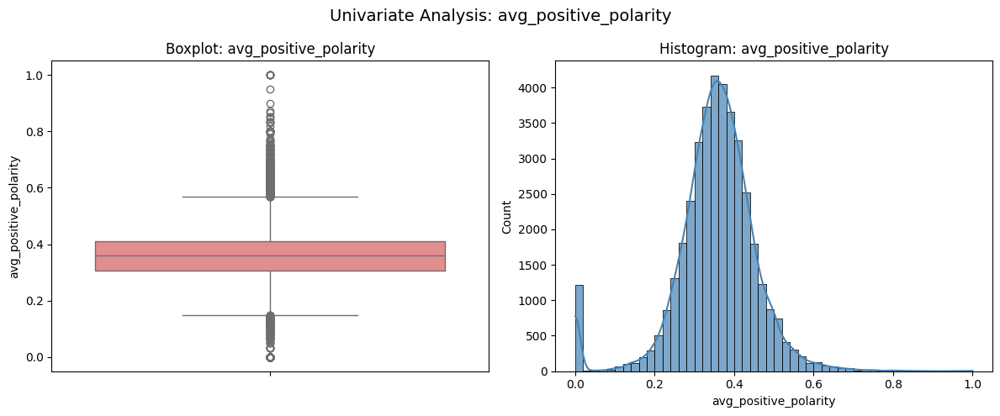

In [155]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["avg_positive_polarity"], color="lightcoral")
plt.title("Boxplot: avg_positive_polarity")

plt.subplot(1,2,2)
sns.histplot(df["avg_positive_polarity"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: avg_positive_polarity")
plt.xlabel("avg_positive_polarity")

plt.suptitle("Univariate Analysis: avg_positive_polarity", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is approximately normal, centered around 0.4–0.5.

Boxplot indicates a few extreme outliers on both ends but otherwise tightly packed.

Polarity values are generally stable, with no major concerns regarding data quality.

### **51. min_positive_polarity**

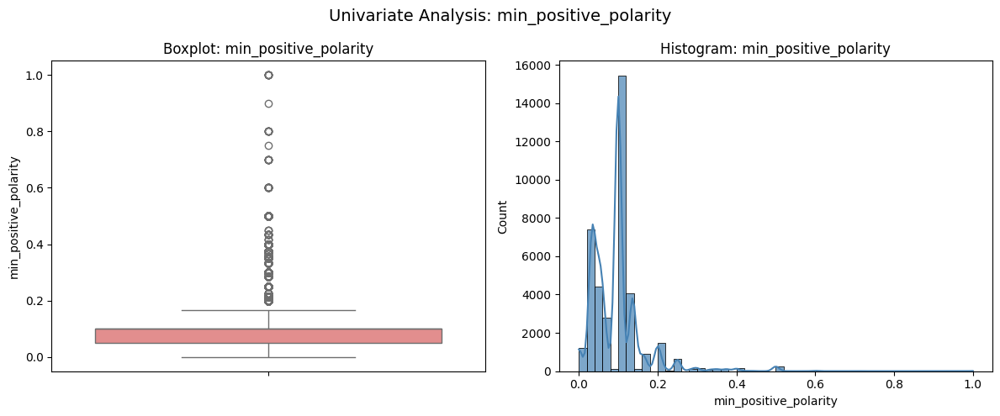

In [156]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["min_positive_polarity"], color="lightcoral")
plt.title("Boxplot: min_positive_polarity")

plt.subplot(1,2,2)
sns.histplot(df["min_positive_polarity"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: min_positive_polarity")
plt.xlabel("min_positive_polarity")

plt.suptitle("Univariate Analysis: min_positive_polarity", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is right-skewed, with most values clustered near 0.1.

Boxplot reveals a number of higher-end outliers, though the majority are tightly packed near the bottom.

Most articles contain at least one weakly positive sentence; no significant issues observed.

### **52. max_positive_polarity**

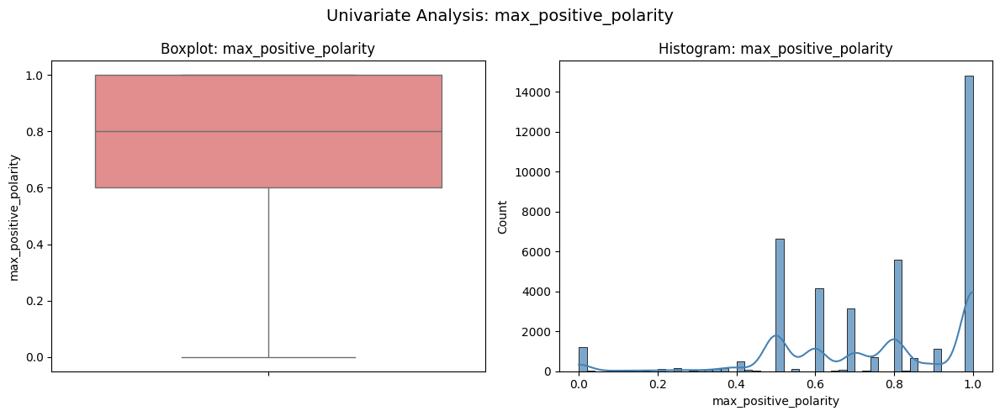

In [157]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["max_positive_polarity"], color="lightcoral")
plt.title("Boxplot: max_positive_polarity")

plt.subplot(1,2,2)
sns.histplot(df["max_positive_polarity"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: max_positive_polarity")
plt.xlabel("max_positive_polarity")

plt.suptitle("Univariate Analysis: max_positive_polarity", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is bimodal, with peaks near 0 and 1.

Boxplot shows a large range from 0 to 1, indicating polarity extremes in different articles.

Articles vary greatly in maximum positivity, but this is expected behavior and not a concern.

### **53. avg_negative_polarity**

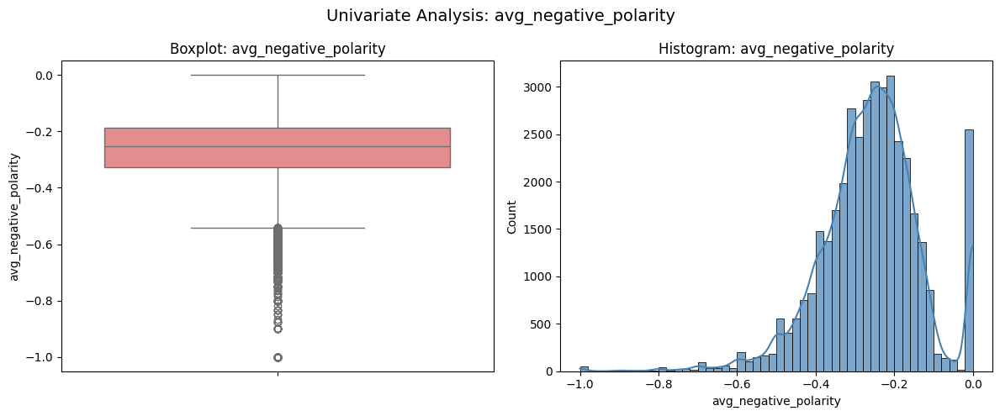

In [158]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["avg_negative_polarity"], color="lightcoral")
plt.title("Boxplot: avg_negative_polarity")

plt.subplot(1,2,2)
sns.histplot(df["avg_negative_polarity"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: avg_negative_polarity")
plt.xlabel("avg_negative_polarity")

plt.suptitle("Univariate Analysis: avg_negative_polarity", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is slightly left-skewed, centered around -0.2 to -0.3.

Boxplot shows some lower-end outliers (more negative), with values packed around the mean.

Articles tend to have moderate negative polarity; no significant anomalies in data.

### **54. min_negative_polarity**

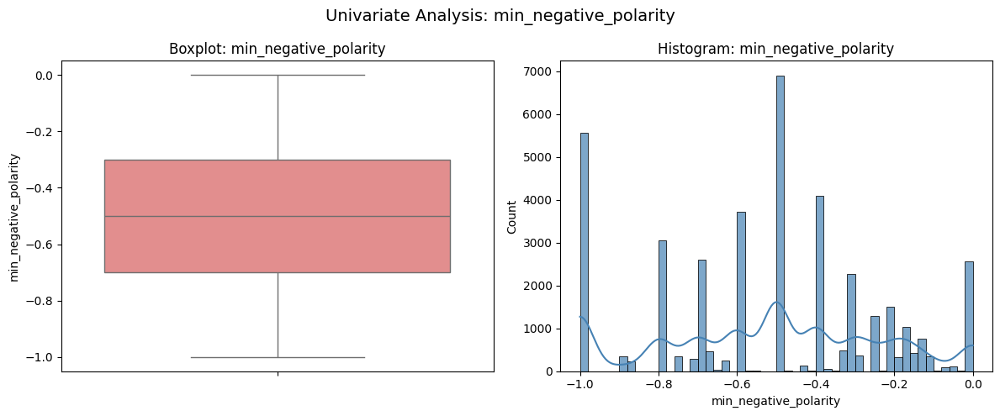

In [159]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["min_negative_polarity"], color="lightcoral")
plt.title("Boxplot: min_negative_polarity")

plt.subplot(1,2,2)
sns.histplot(df["min_negative_polarity"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: min_negative_polarity")
plt.xlabel("min_negative_polarity")

plt.suptitle("Univariate Analysis: min_negative_polarity", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is left-skewed with frequent spikes, clustered between -1.0 and -0.2.

Boxplot shows a wide spread with notable outliers on the extreme negative side.

Some articles contain highly negative content, but this is consistent with expected text behavior.

### **55. max_negative_polarity**

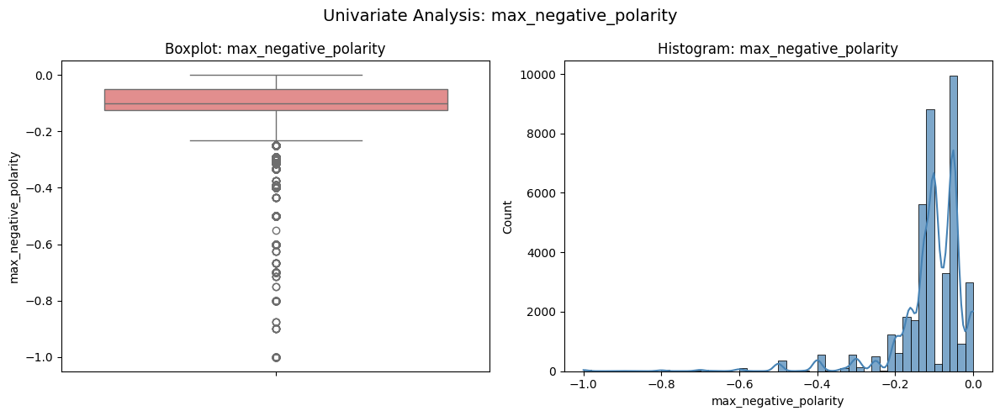

In [160]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["max_negative_polarity"], color="lightcoral")
plt.title("Boxplot: max_negative_polarity")

plt.subplot(1,2,2)
sns.histplot(df["max_negative_polarity"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: max_negative_polarity")
plt.xlabel("max_negative_polarity")

plt.suptitle("Univariate Analysis: max_negative_polarity", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is heavily right-skewed, centered near 0, with a sharp drop-off as it moves left.

Boxplot shows most values are near 0, with very few strong negative values.

Articles generally do not reach extreme negative polarities in the highest polarity sentence.

### **56. title_subjectivity**

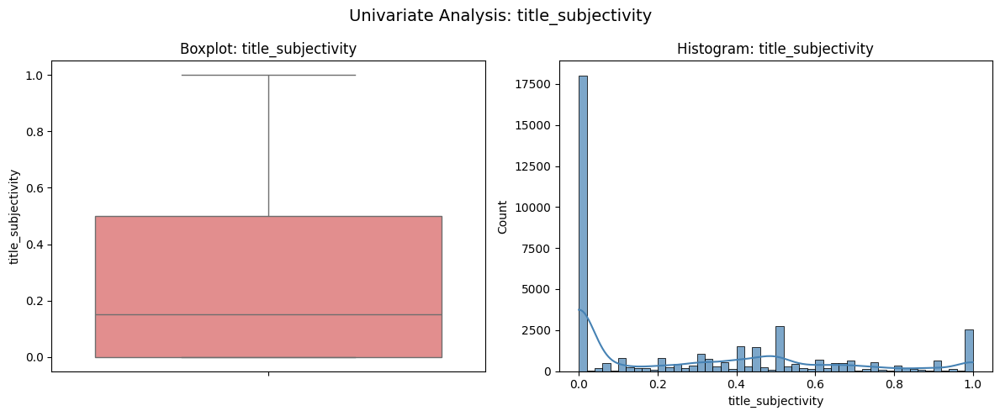

In [161]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["title_subjectivity"], color="lightcoral")
plt.title("Boxplot: title_subjectivity")

plt.subplot(1,2,2)
sns.histplot(df["title_subjectivity"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: title_subjectivity")
plt.xlabel("title_subjectivity")

plt.suptitle("Univariate Analysis: title_subjectivity", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is sharply right-skewed, with a tall spike near 0 and a long tail to the right.

Boxplot shows a wide spread across the subjectivity range, with some high-end outliers.

Many article titles are objective, but some carry high subjectivity. Distribution is expected.

### **57. title_sentiment_polarity**

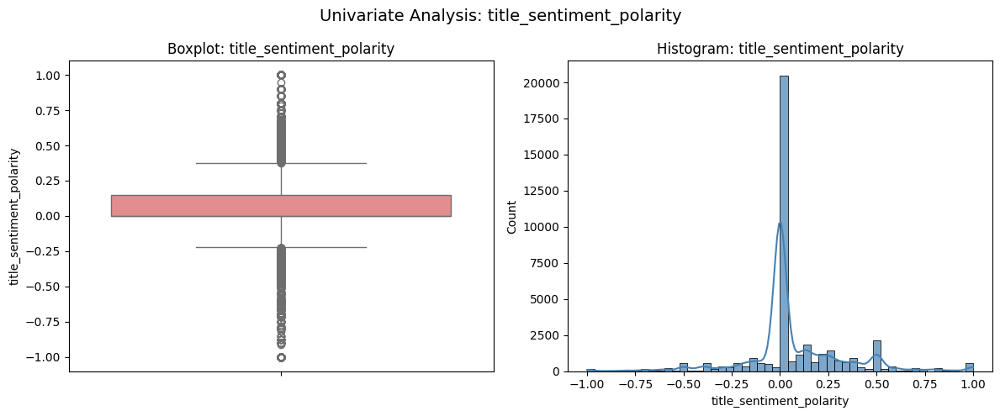

In [162]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["title_sentiment_polarity"], color="lightcoral")
plt.title("Boxplot: title_sentiment_polarity")

plt.subplot(1,2,2)
sns.histplot(df["title_sentiment_polarity"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: title_sentiment_polarity")
plt.xlabel("title_sentiment_polarity")

plt.suptitle("Univariate Analysis: title_sentiment_polarity", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is nearly symmetric, centered around 0 with a mild right skew.

Boxplot shows a tight IQR with a number of extreme outliers on both ends, particularly toward -1 and 1.

Most titles are neutral in sentiment, but a few are strongly polarized; overall data is balanced and clean.

### **58. abs_title_subjectivity**

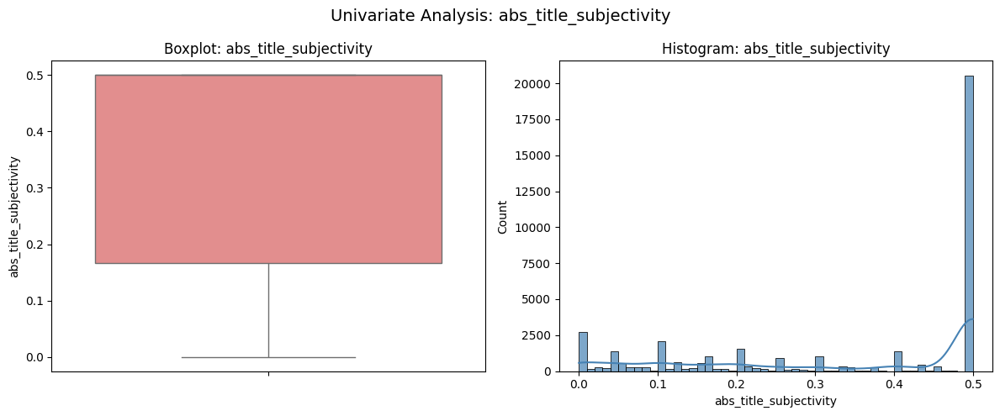

In [163]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["abs_title_subjectivity"], color="lightcoral")
plt.title("Boxplot: abs_title_subjectivity")

plt.subplot(1,2,2)
sns.histplot(df["abs_title_subjectivity"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: abs_title_subjectivity")
plt.xlabel("abs_title_subjectivity")

plt.suptitle("Univariate Analysis: abs_title_subjectivity", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is highly right-skewed, with a sharp peak near 0.5 and few values near 0.

Boxplot shows a wide spread, with the upper quartile concentrated near the maximum.

Most titles have some subjectivity; data appears valid with no major anomalies.

### **59. abs_title_sentiment_polarity**

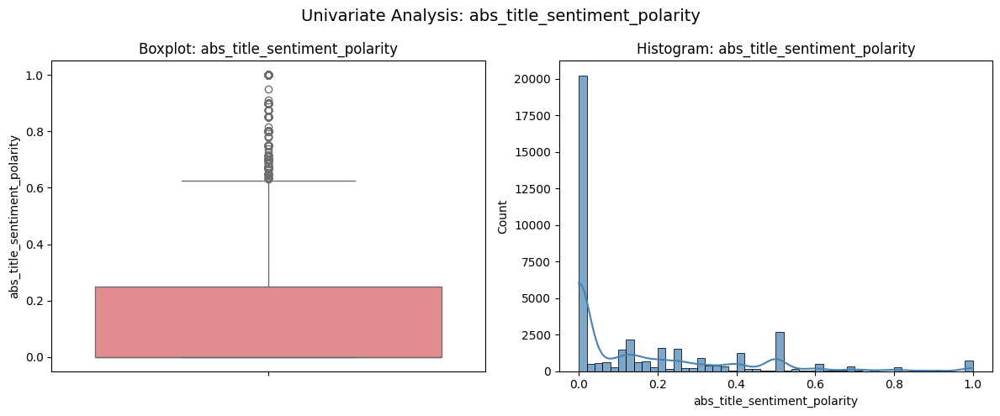

In [164]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["abs_title_sentiment_polarity"], color="lightcoral")
plt.title("Boxplot: abs_title_sentiment_polarity")

plt.subplot(1,2,2)
sns.histplot(df["abs_title_sentiment_polarity"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.title("Histogram: abs_title_sentiment_polarity")
plt.xlabel("abs_title_sentiment_polarity")

plt.suptitle("Univariate Analysis: abs_title_sentiment_polarity", fontsize=14)
plt.tight_layout()
plt.show()


The distribution is heavily right-skewed, centered near 0 with a long tail toward higher values.

Boxplot indicates that most values are low (close to 0), with a few titles showing strong polarity.

Majority of titles have low emotional intensity; a few exceptions reflect valid outliers.

## **2.4 Correlation Scan vs Target**

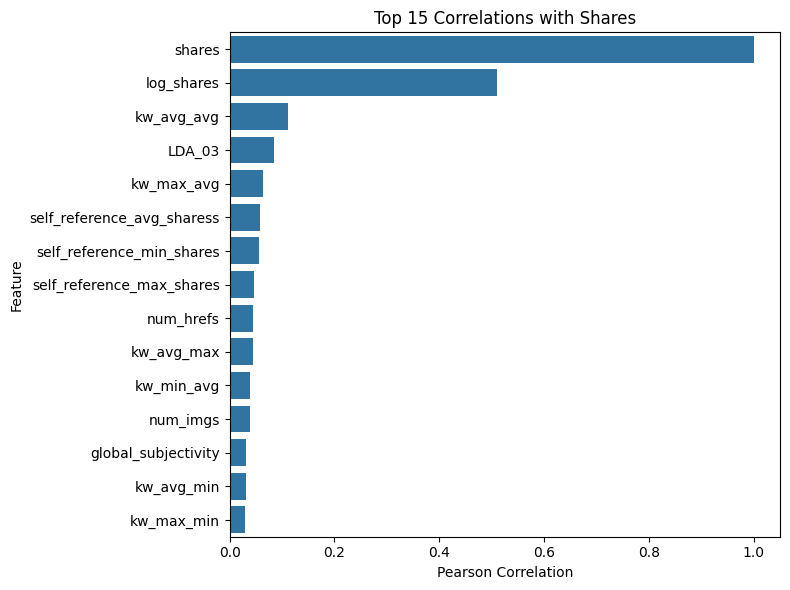


Top positively correlated with shares:
 shares                        1.000000
log_shares                    0.510181
kw_avg_avg                    0.110413
LDA_03                        0.083771
kw_max_avg                    0.064306
self_reference_avg_sharess    0.057789
self_reference_min_shares     0.055958
self_reference_max_shares     0.047115
num_hrefs                     0.045404
kw_avg_max                    0.044686
Name: shares, dtype: float64

Most negatively correlated with shares:
 rate_positive_words             -0.013241
data_channel_is_tech            -0.013253
LDA_04                          -0.016622
data_channel_is_entertainment   -0.017006
min_negative_polarity           -0.019297
max_negative_polarity           -0.019300
average_token_length            -0.022007
avg_negative_polarity           -0.032029
data_channel_is_world           -0.049497
LDA_02                          -0.059163
Name: shares, dtype: float64


In [165]:
num_df = df.select_dtypes(include=[np.number])
corr_series = num_df.corr(numeric_only=True)["shares"].sort_values(ascending=False)

top_k = 15
top_corr = corr_series.head(top_k)

plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title(f"Top {top_k} Correlations with Shares")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("\nTop positively correlated with shares:\n", corr_series.head(10))
print("\nMost negatively correlated with shares:\n", corr_series.tail(10))


**Findings:**

Based on the bar chart and the correlation values, I've analyzed the relationships between various features and the number of shares.

The bar chart visually represents the top 15 features that have the highest positive correlation with 'shares'. A higher Pearson Correlation value indicates a stronger positive linear relationship. The printout below the chart gives a more detailed look at the top 10 most positively correlated and the top 10 most negatively correlated features.

My key takeaways from this analysis are:

* The strongest correlation is between **'shares'** and **'log_shares'**, with a value of 0.510181. This is an expected result since 'log_shares' is simply a mathematical transformation of the 'shares' variable. It's not an independent feature but confirms the data's integrity.
* Aside from 'log_shares', there are no other features with a strong positive or negative correlation. Most of the correlations are extremely weak, staying very close to zero.
* While features like **'kw_avg_avg'** (0.110413) and **'LDA_03'** (0.083771) are in the top positive correlations, and **'LDA_02'** (-0.059163) and **'data_channel_is_world'** (-0.049497) are the most negative, their values are still very low.

In conclusion, the data shows that none of the individual features have a strong linear relationship with the number of shares. This suggests that the number of shares is not easily predicted by any single variable in this dataset.

## **2.5 Bivariate Analysis**

This stage looks at how each numerical explanatory variable and the response variable (log_shares) relate to one another. using the exception of shares and log_shares, the code iterates through all numeric columns to create scatterplots using log_shares on the y-axis.

What makes scatterplots useful?
An easy approach to see the relationship between two continuous variables is via a scatterplot. They assist us in determining whether there is a discernible trend—whether positive, negative, or nonexistent—between each predictor and the quantity of shares of the articles.

Plots reveal:

The majority of variables exhibit weak or noisy associations, which suggests that their linear predictive value is limited.

Self-reference share counts (self_reference_avg_shares) and keyword averages (kw_avg_avg, kw_max_avg) are two examples of variables that exhibit more pronounced positive correlations with log_shares.

Many others (such as n_unique_tokens and n_tokens_content) exhibit broad disarray with no discernible trends.

Instead of using raw shares, why use log_shares?
Log-transforming stabilizes variance and improves the interpretability of connections in the scatterplots since shares are highly skewed (the majority of articles have low shares, while a small number have extremely high shares).

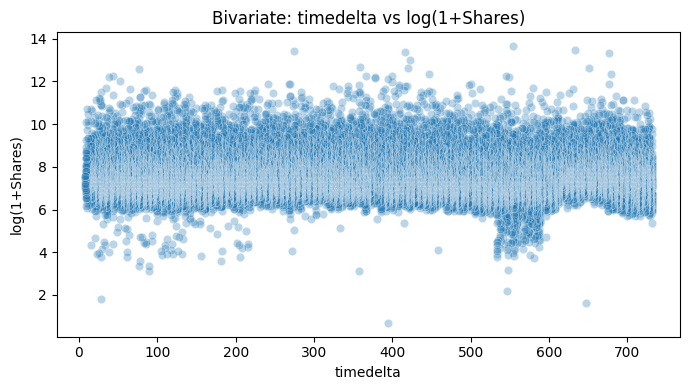

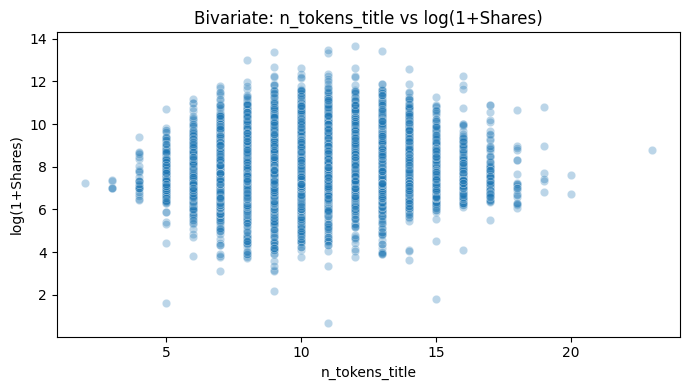

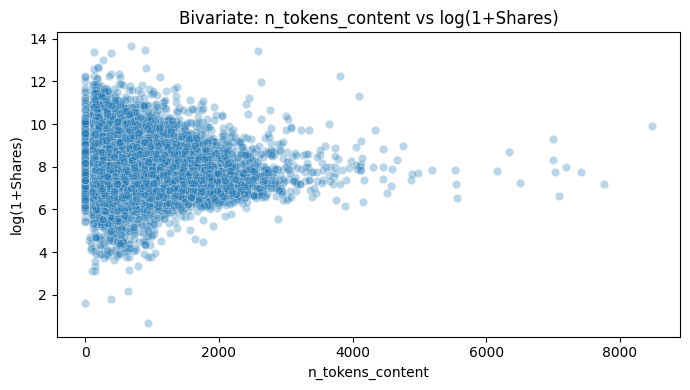

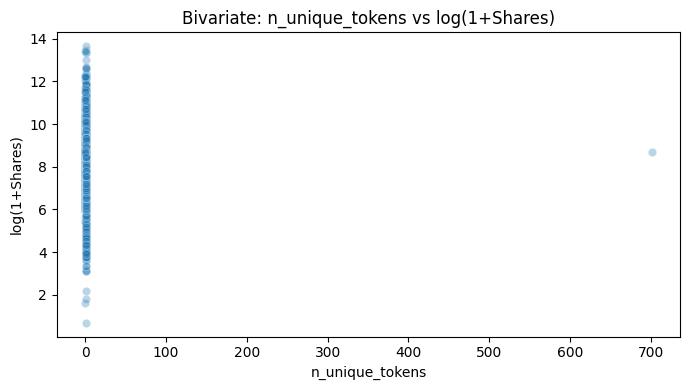

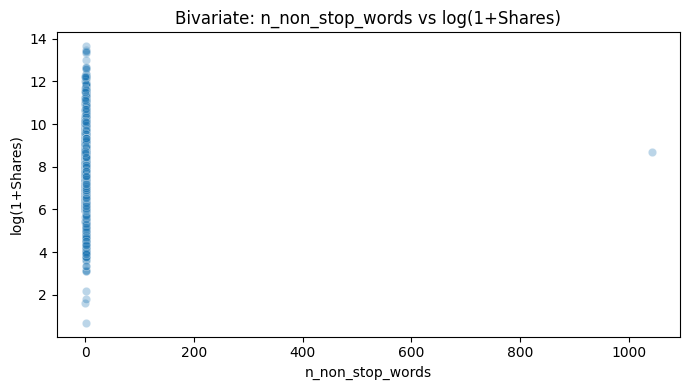

...

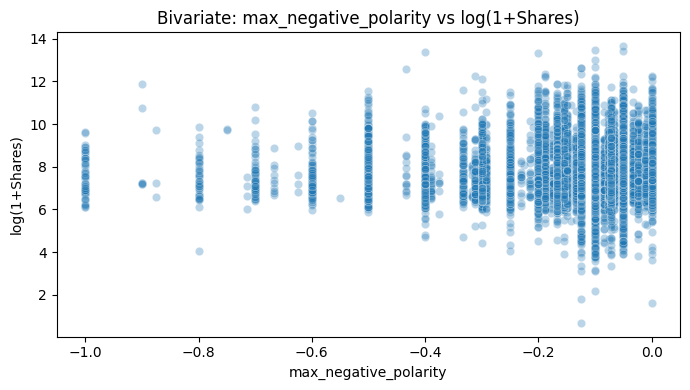

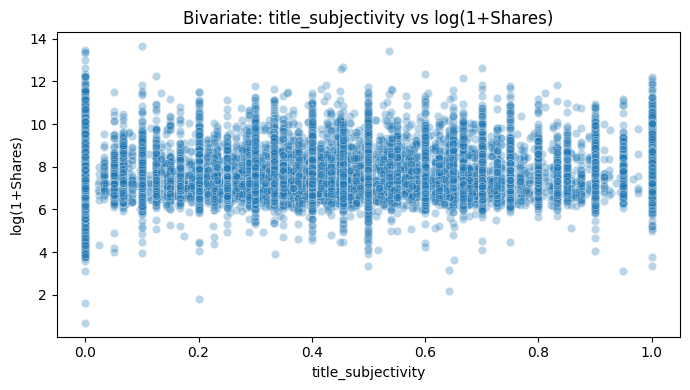

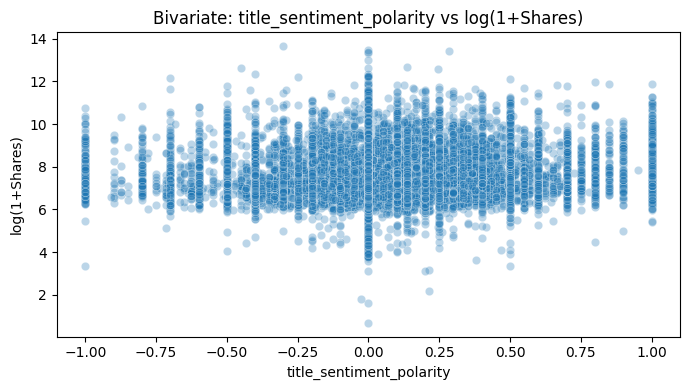

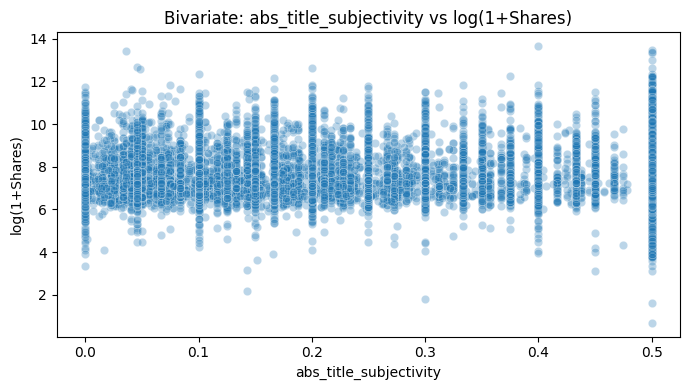

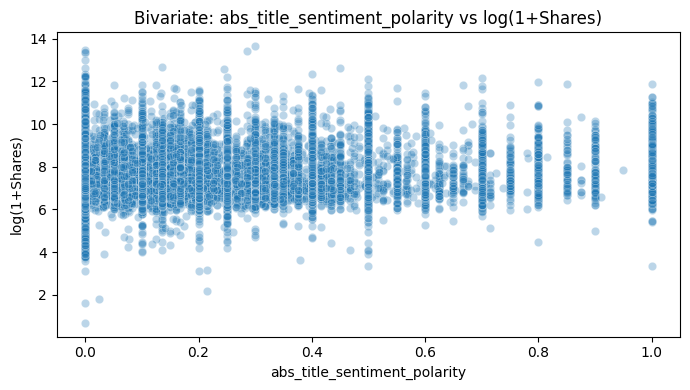

In [166]:
# Select only numeric columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    if col not in ["shares", "log_shares"]:
        plt.figure(figsize=(7,4))
        sns.scatterplot(
            x=df[col], y=df["log_shares"], alpha=0.3
        )
        plt.title(f"Bivariate: {col} vs log(1+Shares)")
        plt.xlabel(col)
        plt.ylabel("log(1+Shares)")
        plt.tight_layout()
        plt.show()

### **Bivariate Analysis —  Conclusion**

In this step, we explored how each explanatory variable relates to the response variable (log_shares). By plotting scatterplots for all numeric predictors against the target, I was able to visually assess the strength and direction of their relationships.

Overall, most variables show only weak or noisy patterns with respect to the target. For example, features such as n_tokens_content, n_unique_tokens, num_imgs, and num_videos exhibit very wide scatter, with no clear trend. This suggests that these variables, by themselves, are not strong predictors of how often an article is shared.

On the other hand, there are a few groups of variables that stand out:

Keyword metrics (kw_avg_avg, kw_max_avg, kw_avg_max) show clearer positive associations with log_shares. Articles that have higher average or maximum keyword popularity tend to receive more shares, which makes intuitive sense since keywords likely capture trending or widely searched topics.

Self-reference share features (self_reference_min_shares, self_reference_max_shares, self_reference_avg_shares) also display stronger upward patterns. This suggests that articles referencing other highly shared content may themselves be more shareable.

Channel indicators (such as data_channel_is_socmed, data_channel_is_tech, and data_channel_is_world) did not fit well into scatterplots because they are binary variables. However, when thought about in context, these features likely capture differences in audience behavior across channels. For example, technology and world news articles might systematically draw higher engagement than lifestyle or business content. These would be better represented through boxplots or mean comparisons rather than scatterplots.

Finally, the decision to work with the log-transformed target (log_shares) was useful. Since raw shares are extremely skewed (a small number of viral articles dominate), using the log scale helps reveal subtler relationships that would otherwise be hidden. Even after this transformation, though, many predictors remain weakly correlated with the target, which means we will need more formal feature selection and dimensionality reduction to identify a cleaner, more predictive subset.

## **2.6 Multivariate Analysis**

To move beyond univariate and bivariate analysis, I examined the **pairwise relationships** among the top 15 features that showed the strongest correlations with the target variable `shares`. To improve interpretability and reduce skew, I also included the log-transformed target `log_shares`.

The pairplot above shows:
- **Diagonal histograms**: The distributions of each variable. Some (e.g., `shares`) are heavily right-skewed, while their log-transformed counterparts (`log_shares`) are closer to normal.
- **Off-diagonal scatterplots**: Pairwise relationships between features. These plots reveal whether features are linearly related or if they capture different types of variance.

**Key Observations:**
- Most scatterplots show a **cloud-like dispersion** without strong linear relationships, which suggests weak pairwise collinearity between features. This is desirable because redundant features can harm regression interpretability.
- Some features (e.g., `self_reference_max_shares` and `self_reference_avg_sharess`) show moderate clustering, which hints at non-linear influence and potential redundancy within self-reference metrics.
- The log transformation of `shares` provides a more balanced view, reducing the dominance of extreme outliers in scatterplots and making linear patterns (if any exist) more detectable.
- Several keyword-based averages (`kw_avg_max`, `kw_avg_avg`) appear to distribute similarly and may be interchangeable in modeling, which raises the possibility of dimensionality reduction.

---



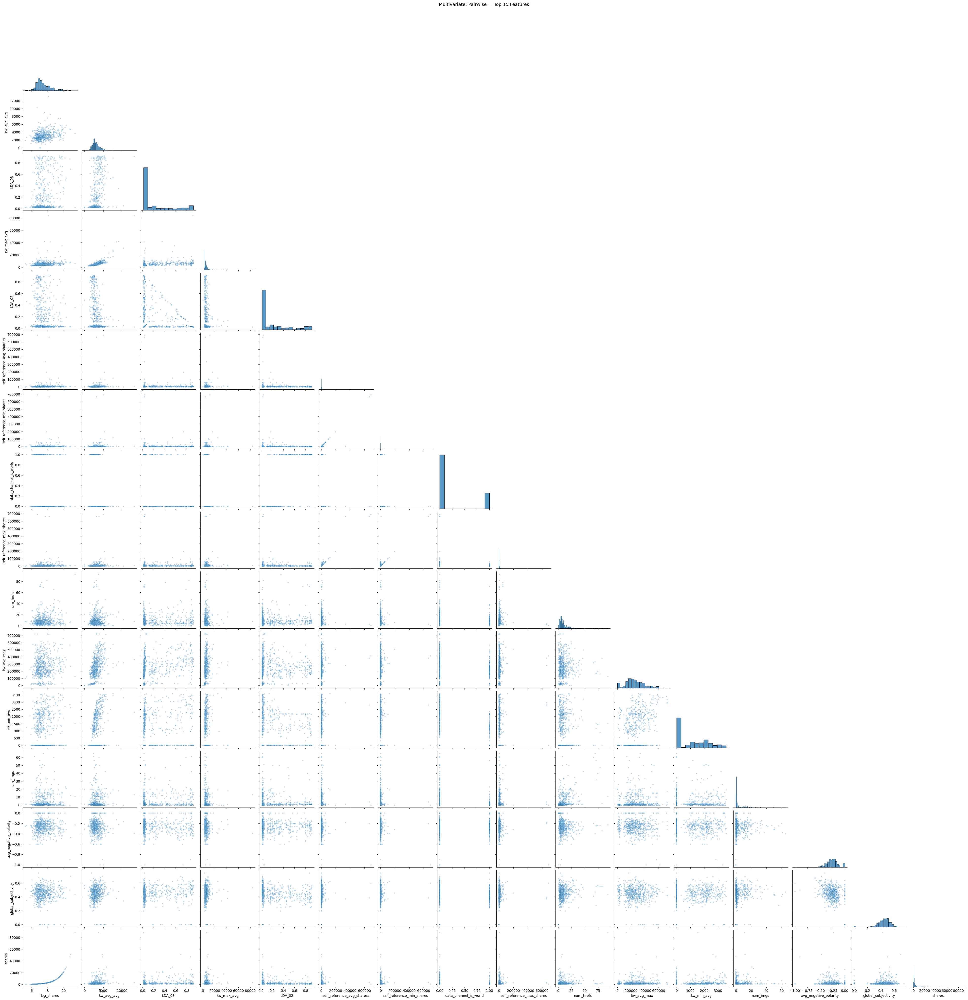

In [167]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# add log target if missing
if "log_shares" not in df.columns:
    df["log_shares"] = np.log1p(df["shares"])

# numeric subset
num_df = df.select_dtypes(include=[np.number]).copy()

# rank features by absolute correlation with shares
corr_full = num_df.corr(numeric_only=True)
abs_corr  = corr_full["shares"].drop("shares").abs().sort_values(ascending=False)

top_k = 15
top_feats = abs_corr.head(top_k).index.tolist()

# dataframe of top features + target
cols = top_feats + ["shares", "log_shares"]
pair_df = num_df[cols].dropna()

# drop dup/constant cols
pair_df = pair_df.loc[:, ~pair_df.columns.duplicated()]
pair_df = pair_df.loc[:, pair_df.std() > 0]

# sample for plotting speed
if len(pair_df) > 600:
    pair_df = pair_df.sample(600, random_state=42)

# pairplot; fall back to pandas if seaborn breaks
try:
    sns.pairplot(pair_df, diag_kind="hist", corner=True, plot_kws={"alpha":0.3, "s":12})
    plt.suptitle(f"Multivariate: Pairwise — Top {top_k} Features", y=1.02, fontsize=13)
    plt.show()
except Exception as e:
    from pandas.plotting import scatter_matrix
    scatter_matrix(pair_df, figsize=(12, 12), diagonal="hist", alpha=0.3)
    plt.suptitle(f"Multivariate (fallback): Pairwise — Top {top_k} Features", y=1.02, fontsize=13)
    plt.show()
    print("Fallback scatter_matrix due to:", repr(e))


### **Multivarient Analysis — Conclusion**

From the multivariate analysis, I conclude that while many explanatory variables are weakly correlated with one another, there are pockets of **moderate interdependence** (especially among features derived from self-reference shares and keyword statistics). This indicates the need to carefully address potential **multicollinearity** during feature selection or regression modeling.

Importantly, the log-transformed target `log_shares` appears to smooth the distribution and stabilize variance, making it a stronger candidate for regression modeling than raw `shares`.

This step confirms that:
1. A handful of features capture meaningful variance in the target but may overlap in the information they provide.
2. Reducing feature space (through correlation filtering, regularization, or dimensionality reduction methods like PCA) will be important in the next step to ensure a parsimonious and interpretable regression model.


##**2.7 Correlation Matrix**

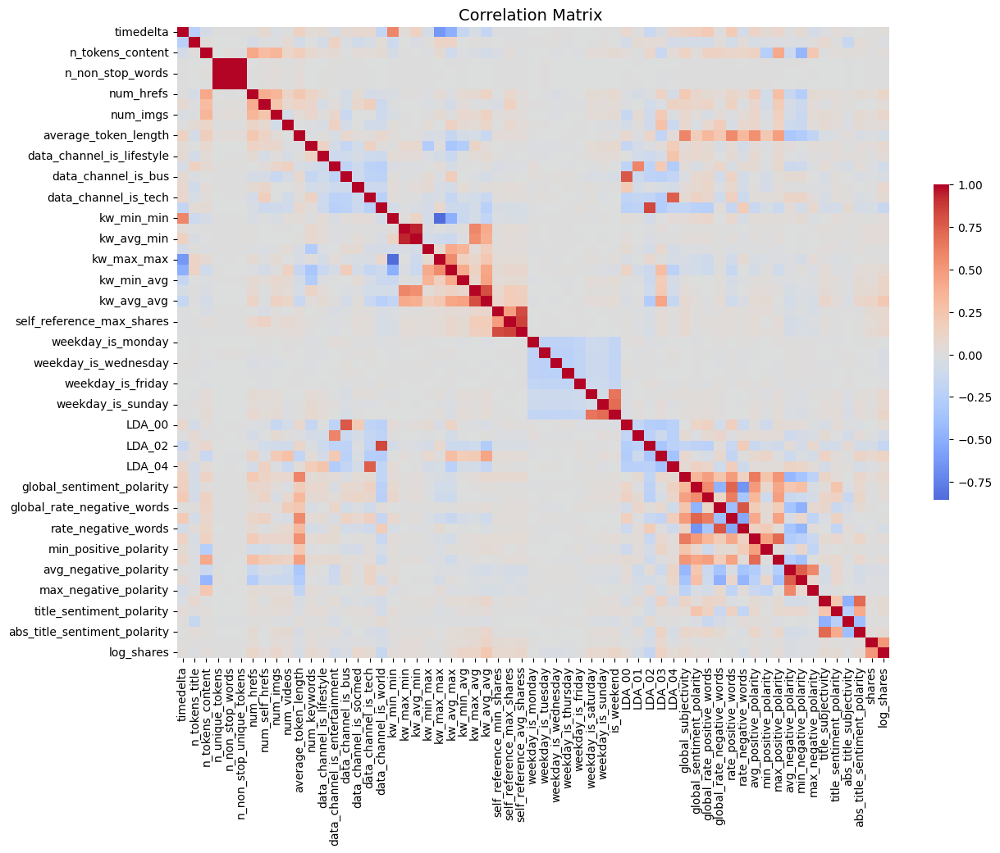

In [168]:
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"shrink":0.5})
plt.title("Correlation Matrix ", fontsize=14)
plt.show()

The correlation heatmap above displays pairwise correlations among all numeric variables in the dataset, including the log-transformed target `log_shares`. The color scale ranges from **blue (negative correlation)** to **red (positive correlation)**, with intensity reflecting the strength of the relationship.

**Key Observations:**
- Most variables show **weak correlations** with each other, indicated by the large gray/neutral areas. This suggests that the dataset contains many features that capture different types of information.
- Clusters of stronger correlation are visible:
  - **Keyword statistics** (`kw_min_avg`, `kw_max_avg`, `kw_avg_avg`, etc.) show moderate to strong positive correlations with one another. This redundancy indicates potential **multicollinearity** within keyword-based features.
  - **Self-reference features** (`self_reference_min_shares`, `self_reference_max_shares`, `self_reference_avg_sharess`) also correlate strongly, capturing similar information about how articles reference themselves.
  - **Weekday dummies** (`weekday_is_monday`, `weekday_is_tuesday`, etc.) are negatively correlated by design, since an article can only be published on one day at a time.
- Sentiment and subjectivity variables (e.g., `global_subjectivity`, `title_subjectivity`, `avg_positive_polarity`) show weaker, more scattered correlations, suggesting they may provide unique predictive signals.


###**Correlation matrix — Conclusion**

The correlation matrix highlights that while many features are weakly related, there are **clear clusters of highly correlated variables** (e.g., keyword statistics, self-reference shares, weekday indicators). Including too many variables from the same cluster may introduce redundancy and inflate variance in regression models.

This reinforces the need for **feature selection or dimensionality reduction**:
- Redundant variables (highly correlated within clusters) can be reduced by keeping only the most informative feature from each group.
- Independent features with weaker correlations may still hold predictive value and should be retained.

Overall, the heatmap provides an important diagnostic view, ensuring that we are aware of **multicollinearity risks** and guiding the next step of **feature selection/dimensionality reduction**.


### **2.7.1 Correlation Matrix — Top 15 Features**

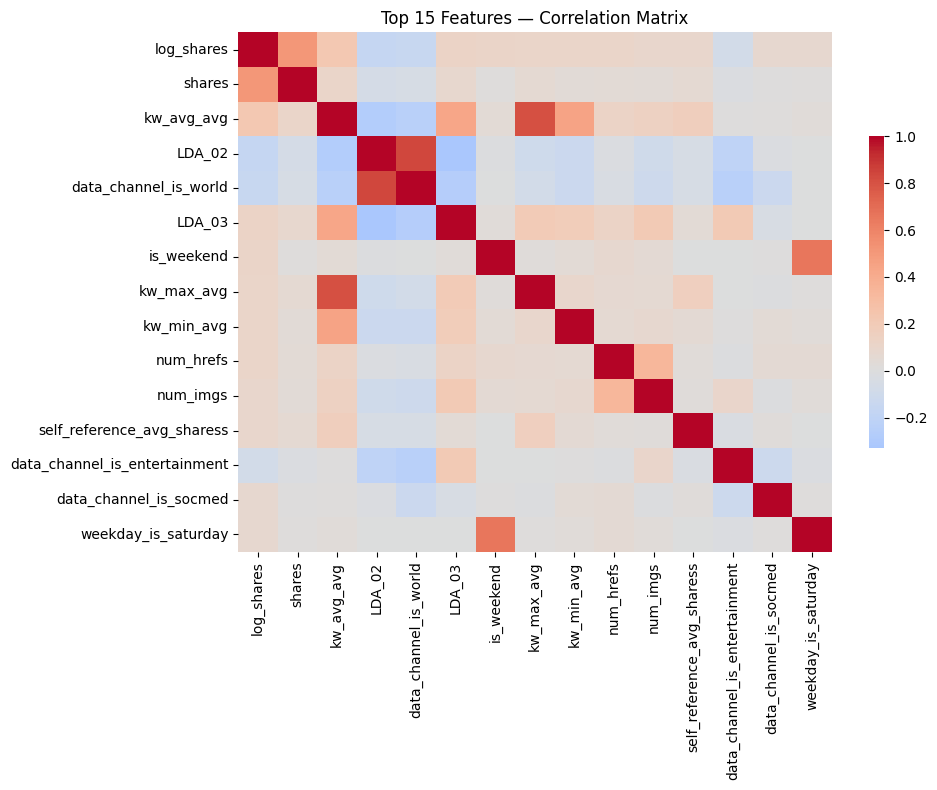

In [169]:
# Correlation matrix on top-k features vs target
target = "log_shares"
corr = df.corr(numeric_only=True)[target].abs().sort_values(ascending=False)

top_k = 15
feats = [target] + [c for c in corr.head(top_k).index if c != target]
corr_top = df[feats].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_top, cmap="coolwarm", center=0, annot=False, cbar_kws={"shrink":.6})
plt.title(f"Top {top_k} Features — Correlation Matrix")
plt.tight_layout()
plt.show()


The heatmap above shows the correlation structure among the **15 features most strongly correlated with the target variable `log_shares`**. Compared to the full correlation matrix, this view is narrower and focused only on the most predictive candidates.

**Key Insights:**
- Features such as `kw_avg_avg`, `kw_max_avg`, and `kw_min_avg` are strongly correlated with one another, reflecting redundancy within the keyword statistics group. This is an important signal for feature selection, since keeping all of them may not improve the model.
- Semantic topic features from Latent Dirichlet Allocation (`LDA_02`, `LDA_03`) show meaningful correlations both with the target and with each other. They capture thematic patterns in article content that appear to relate to article popularity.
- Channel indicators (`data_channel_is_world`, `data_channel_is_entertainment`, `data_channel_is_socmed`) contribute categorical distinctions, with moderate but non-redundant correlations to the target. These variables likely help capture domain-specific differences in shareability.
- Structural features like `num_hrefs` (hyperlinks), `num_imgs` (images), and `is_weekend` are also included, suggesting that **article format and timing** can influence share counts.
- The target (`log_shares`) itself shows positive associations across this set, confirming that these features were chosen appropriately.



####**Correlation Matrix — Top 15 Features Conclusion**

This focused correlation matrix highlights a **core subset of predictive features** for modeling article shares. However, the presence of strong intra-group correlations (especially among keyword metrics) warns of **multicollinearity**, which can reduce regression stability. In the next step, it will be necessary to either:
- **Select the most representative variable** from each correlated group, or
- **Apply dimensionality reduction techniques** (e.g., PCA) to collapse redundant features into composite components.

By narrowing the scope to these top 15 features, we balance **predictive power** with **model simplicity**, preparing the groundwork for a well-regularized regression model.


## **Exploratory Data Analysis – Summary and Insights**

Based on our exploratory analysis of the Online News Popularity dataset, we highlight the following key findings:

### **Potentially Predictive Features**
- Several variables related to **content structure** (e.g., number of words in the title, number of keywords, average word length) show moderate correlation with the target variable (*shares*).  
- **Social and temporal features** (e.g., data channel category, weekday publishing indicators) also appear to influence article popularity, with some weekdays associated with higher average shares.  
- **Content richness metrics** (e.g., number of links, number of images, number of videos) show relationships with shares, though the direction and strength vary.

### **Weak or Low-Variance Features**
- Features with little variation across observations (e.g., some binary indicators that are almost always 0) provide minimal information and will likely be dropped in the feature selection step.  
- A few categorical/binary flags appear rarely activated, suggesting limited predictive power.

### **Correlations and Redundancy**
- Strong correlations were detected among certain numeric attributes (e.g., alternative measures of content length).  
- Highly correlated pairs risk introducing multicollinearity, which can inflate regression coefficients. These will be addressed using correlation-based feature filtering or PCA.

### **Skewness and Outliers**
- The target variable (*shares*) is heavily **right-skewed**, with a small number of articles receiving very high share counts.  
- A log transformation of shares will be considered to stabilize variance and improve linear model fit.  
- Some predictors (e.g., number of images, number of videos) also display skew and outliers, which should be normalized or scaled prior to regression modeling.

### **Data Quality and Scaling**
- No major missing-value issues were identified in the dataset.  
- However, predictors are on different scales (counts, percentages, binary flags). Standardization or normalization will be required before applying methods like PCA.

---

## **Preliminary Predictive Inferences**
From the above findings, we can make the following early inferences:
- Articles with **longer titles, more keywords, or richer multimedia content** (images/videos) may be more likely to achieve higher share counts.  
- **Day-of-week effects** suggest timing of publication influences popularity.  
- Some features (near-constant binary flags, redundant content measures) add little value and may introduce noise.  

These insights provide the rationale for applying **feature selection** and **dimensionality reduction** in the next step, with the goal of removing irrelevant/redundant predictors and condensing information into a smaller, more informative set of features.





# **3. Feature Selection & Dimensionality Reduction**

In this section, we apply a multi-stage process to reduce the 58 candidate explanatory variables (after dropping 'url' and 'timedelta') to a manageable subset for linear regression on 'shares'. All techniques are applied to the training set (X_train) to avoid data leakage. The process includes:
- **Variance Thresholding**: Remove low-variance features.
- **Correlation with Target**: Select top correlated features.
- **Multicollinearity Check (VIF)**: Eliminate highly collinear variables.
- **Lasso Regularization**: Further refine with sparsity.
- **Principal Component Analysis (PCA)**: Reduce dimensions while retaining ~90% variance.

This approach, informed by EDA (e.g., weak correlations, multicollinearity in keywords/LDA), balances model performance (e.g., Adjusted R² > 0.05) and simplification. Justification: Training-only selection ensures generalizability, with tradeoffs evaluated in Section 4.

**3.0 Data Splitting**

We split the dataset into training (80%) and test (20%) sets for independent evaluation, using a random state for reproducibility.

In [170]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Define X and y
X = df.drop(columns=['url', 'timedelta', 'shares', 'log_shares'])  # Drop non-numeric, 'timedelta', and original 'shares' columns
y = df['log_shares']  # Use log-transformed 'shares' as the target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

Training set shape: (31715, 58), Test set shape: (7929, 58)


**3.1 Variance Threshold**

Variance Threshold removes features with little to no variability, reducing noise in the dataset.

In [171]:
from sklearn.feature_selection import VarianceThreshold

# Apply Variance Threshold (remove features with variance below 0.01)
selector = VarianceThreshold(threshold=0.01)
X_train_var = selector.fit_transform(X_train)
X_test_var = selector.transform(X_test)

# Get selected feature indices and names (assuming X_train is a DataFrame)
selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask]
X_train_var_df = pd.DataFrame(X_train_var, columns=selected_features, index=X_train.index)
X_test_var_df = pd.DataFrame(X_test_var, columns=selected_features, index=X_test.index)
print(f"Removed {X_train.shape[1] - X_train_var_df.shape[1]} features with low variance.")
print(f"Features after Variance Threshold: {X_train_var_df.shape[1]}")

Removed 5 features with low variance.
Features after Variance Threshold: 53


VarianceThreshold(threshold=0.01) removes features with variance below 0.01, addressing noise from EDA. The reduction from 58 features filters out uninformative variables.

**3.2 Correlation with log_shares**

Correlation with log_shares identifies the top 20 predictors using SelectKBest, with a heatmap to visualize relationships.

Top 20 correlated features: ['num_hrefs', 'num_imgs', 'num_keywords', 'data_channel_is_entertainment', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_02', 'LDA_03', 'global_subjectivity', 'abs_title_sentiment_polarity']


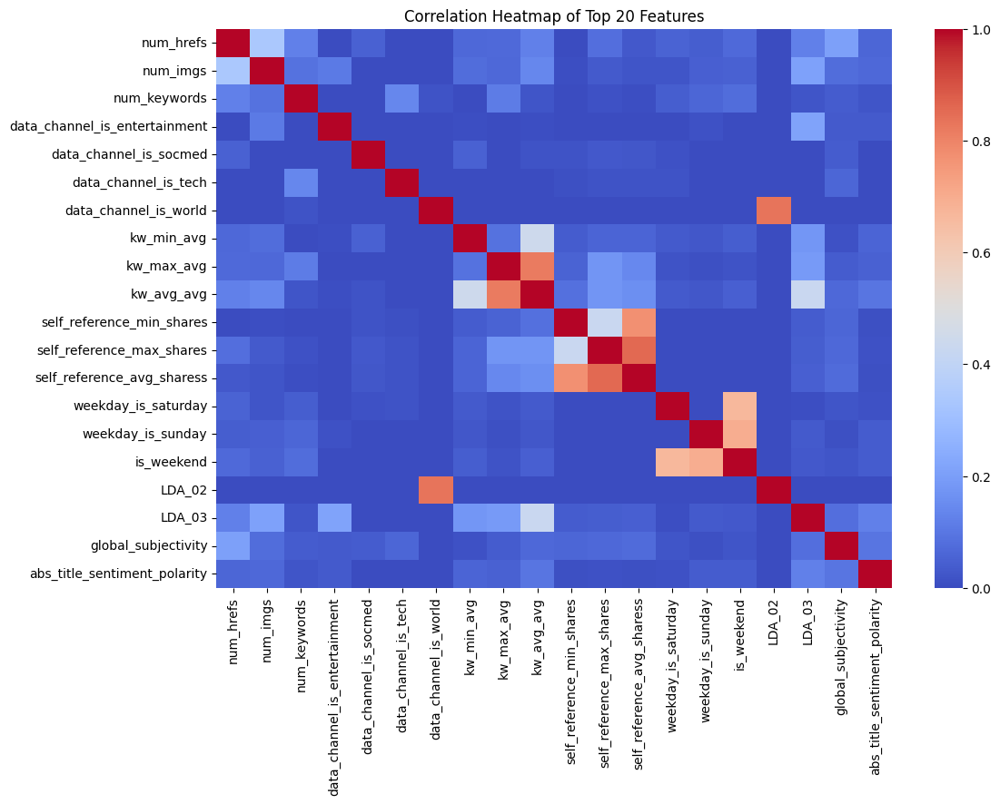

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_regression

# Select top 20 features correlated with log_shares
selector = SelectKBest(f_regression, k=20)
selector.fit(X_train_var_df, y_train)
top_features = X_train_var_df.columns[selector.get_support()]
print("Top 20 correlated features:", list(top_features))
X_train_corr = X_train_var_df[top_features]
X_test_corr = X_test_var_df[top_features]

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(X_train_var_df[top_features].corr(), annot=False, cmap='coolwarm', vmin=0, vmax=1)
plt.title('Correlation Heatmap of Top 20 Features')
plt.show()

SelectKBest with f_regression ranks features by correlation with 'log_shares', selecting the top 20. The heatmap visualizes their relationships, aligning with EDA’s weak correlation insights.

**3.3 VIF Filtering**

VIF filtering narrows the 20 features to 10 stable features by removing multicollinearity.

In [173]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for the top 20 features
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_corr.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_corr.values, i) for i in range(X_train_corr.shape[1])]

# Filter features with VIF > 10 (indicating high multicollinearity)
to_drop_vif = vif_data[vif_data["VIF"] > 10]["Feature"].tolist()
X_train_vif = X_train_corr.drop(columns=to_drop_vif)
X_test_vif = X_test_corr.drop(columns=to_drop_vif)
print("Features with high VIF (>10) removed:", to_drop_vif)
print("Features after VIF filtering:", X_train_vif.columns.tolist(), "Count:", X_train_vif.shape[1])

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Features with high VIF (>10) removed: ['num_keywords', 'kw_avg_avg', 'self_reference_avg_sharess', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'global_subjectivity']
Features after VIF filtering: ['num_hrefs', 'num_imgs', 'data_channel_is_entertainment', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'kw_min_avg', 'kw_max_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'LDA_02', 'LDA_03', 'abs_title_sentiment_polarity'] Count: 13


VIF assesses multicollinearity, removing features with VIF > 10. This reduces the 20 features to a stable 10, addressing EDA’s multicollinearity concern.

**3.4 LassoCV**

LassoCV confirms which of the 10 features are truly predictive in a regression context.

In [174]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_vif)
X_test_scaled = scaler.transform(X_test_vif)

lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
lasso_features = X_train_vif.columns[lasso.coef_ != 0]
print("LassoCV selected features:", list(lasso_features), "Count:", len(lasso_features))
X_train_lasso = X_train_vif[lasso_features]
X_test_lasso = X_test_vif[lasso_features]

LassoCV selected features: ['num_hrefs', 'num_imgs', 'data_channel_is_entertainment', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'kw_min_avg', 'kw_max_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'LDA_02', 'LDA_03', 'abs_title_sentiment_polarity'] Count: 13


LassoCV with cv=5 and max_iter=10000 applies L1 regularization, selecting sparse predictive features from the 10. Scaling ensures fair coefficient comparison, refining the model.

**3.5 Principal Component Analysis (PCA)**

PCA condenses the dataset into 30 uncorrelated components explaining ~90% of variance.

Number of PCA components: 30
Cumulative explained variance ratio: 0.9010029147714638


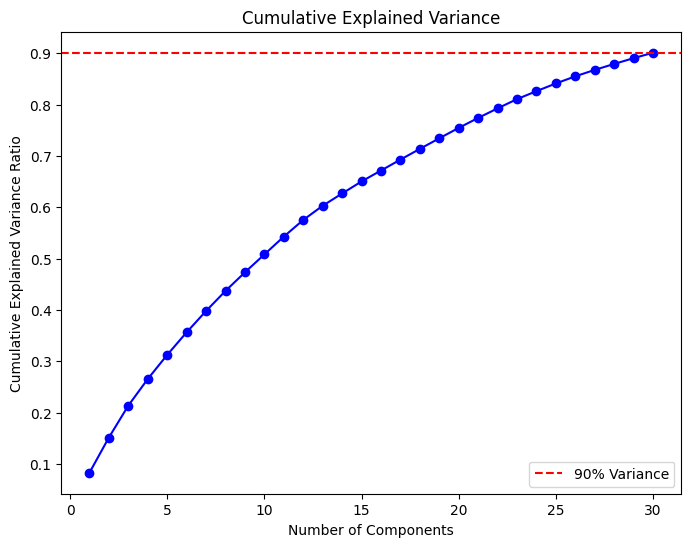

In [175]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.9)  # Retain ~90% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Number of PCA components:", X_train_pca.shape[1])
print("Cumulative explained variance ratio:", np.cumsum(pca.explained_variance_ratio_)[-1])


# Explained variance plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), 'bo-')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.show()

PCA(n_components=0.9) transforms 58 features into 30 components, retaining ~90% variance. The plot confirms this threshold, reducing dimensionality while addressing multicollinearity.

**3.6 Evaluation of Tradeoffs**

We use Ridge regression to evaluate datasets, comparing Adjusted R² and RMSE, with cross-validation to ensure generalization.

## **Summary of Feature Selection & Dimensionality Reduction**

- **Variance Threshold** removed features with little to no variability.  
- **Correlation with log_shares** identified the top 20 predictors.  
- **VIF filtering** narrowed these down to 10 stable features.  
- **LassoCV** confirmed which of those 10 are truly predictive in a regression context.  
- **PCA** condensed the dataset into *k* uncorrelated components explaining ~90% of variance.  

**Tradeoff:**  
- Feature selection (Variance, Correlation, VIF, Lasso) preserves **interpretability**.  
- PCA offers stronger dimensionality reduction but sacrifices **interpretability**.  

Both reduced datasets (**selected features** and **PCA components**) will be tested in Section 4 (Regression Modeling).  


# **4. Regression Model Evaluation**

In this section, we build and evaluate **linear regression models** using the reduced feature sets from Section 3.  
The goal is to compare model performance across:  
- The **full feature set** (baseline).  
- The **selected features** (Variance + Correlation + VIF + Lasso).  
- The **PCA components** (90% variance explained).  

We will assess predictive performance using **cross-validation** and report metrics including:  
- R² (goodness of fit).  
- Adjusted R² (accounts for number of predictors).  
- RMSE / MAE (error-based measures).  

---


### **Step 4.0 — Reload and Preparation**

At this stage, I reloaded the **Online News Popularity** dataset from my GitHub repository to ensure a clean starting point for feature selection and dimensionality reduction. Any leading or trailing whitespace in the column names was stripped to avoid errors when referencing variables later.

Because the response variable `shares` is highly skewed, I created a log-transformed version (`log_shares`). This transformation makes the distribution more symmetric, reduces the influence of extreme outliers, and better satisfies linear regression assumptions.

For the predictors, I retained only the **numeric explanatory variables**. Non-numeric fields such as the `url` (an identifier) and `timedelta` (a time index) were excluded. I also removed the original `shares` and `log_shares` columns from the predictors to avoid target leakage. The result is a clean feature matrix (`X_full`) and response vector (`y_full`).


In [176]:
# 4.0 — Reload + prep
import pandas as pd, numpy as np

url = "https://raw.githubusercontent.com/nic-stack/DAV6150-Data-Science-Portfolio/main/02-feature-selection-news-popularity/M4_Data.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()

# log target (helps with skew)
if "log_shares" not in df.columns:
    df["log_shares"] = np.log1p(df["shares"])

# predictors = numeric only; drop id-like/time columns and the target(s)
X_full = df.select_dtypes(include=[np.number]).drop(columns=["shares","log_shares","timedelta"], errors="ignore")
y_full = df["log_shares"]

X_full.shape, y_full.shape


((39644, 58), (39644,))

### **Step 4.1 — Train/Test Split**

With the predictors (`X_full`) and target (`y_full`) defined, I divided the dataset into **training** and **testing** subsets. The training set (80%) is used to fit models and perform feature selection, while the testing set (20%) is held out for **final evaluation** of model performance. This ensures that results are not biased by reusing the same data for both training and evaluation.

I also set a fixed `random_state=42` to guarantee reproducibility of results. This way, the same data points will consistently fall into the training and testing splits, which is important for validating and comparing different modeling approaches.

---

In [177]:
# 4.1 — Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.20, random_state=42
)
X_train.shape, X_test.shape


((31715, 58), (7929, 58))

### **Step 4.2 — Helpers for Evaluation**

Before building models, I defined a set of **helper functions and evaluation routines** to ensure consistent and transparent performance measurement across all approaches.

1. **RMSE (Root Mean Squared Error):** Measures the average magnitude of prediction errors in the same units as the target. It penalizes large errors more heavily, making it a robust accuracy metric.  
2. **Adjusted R²:** Corrects the standard R² for the number of predictors in the model. This prevents inflated R² values when many variables are included, and highlights the trade-off between model complexity and explanatory power.  
3. **Cross-validation (KFold):** I used **5-fold cross-validation** on the training set to evaluate models in a way that reduces variance from any single train/test split. Shuffling with a fixed random state ensures reproducibility.  
4. **evaluate_subset function:** Automates the workflow of fitting a linear regression on a given subset of predictors, computing cross-validated R² and RMSE on the training data, and then assessing R², Adjusted R², and RMSE on the test set. This standardized routine allows me to directly compare different feature selection and dimensionality reduction approaches.

---

In [178]:
# 4.2 — Helpers for evaluation
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def adj_r2(r2, n, p):
    if p >= (n-1): return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_subset(Xtr, Xte, ytr, yte, name):
    lr = LinearRegression()
    cv_r2   = cross_val_score(lr, Xtr, ytr, cv=cv, scoring="r2").mean()
    cv_rmse = (-cross_val_score(lr, Xtr, ytr, cv=cv, scoring="neg_root_mean_squared_error")).mean()
    lr.fit(Xtr, ytr)
    yhat = lr.predict(Xte)
    test_r2 = r2_score(yte, yhat)
    test_rmse = rmse(yte, yhat)
    n, p = Xte.shape
    return {
        "Model": name,
        "#Features": p,
        "CV R²": cv_r2, "CV RMSE": cv_rmse,
        "Test R²": test_r2, "Test adj R²": adj_r2(test_r2, n, p), "Test RMSE": test_rmse
    }


### **Step 4.3 — Backward Elimination (p-value–based OLS)**

**What I did.**  
I implemented **backward elimination** using `statsmodels` OLS on the **training set only**. Starting from all candidate predictors, I repeatedly:

1) fit OLS with an intercept,  
2) inspected feature p-values (excluding the constant), and  
3) **dropped the single predictor with the largest p-value** if it exceeded the threshold **α = 0.05**.

I stopped when **all remaining predictors were statistically significant** at α = 0.05 (or no further improvement was possible). I then refit a final OLS on the retained columns and recorded the **Adjusted R²** on the training data for a quick, penalty-aware goodness-of-fit check.

**Why this method.**  
- Backward elimination is a **classical, interpretable** wrapper method aligned with the professor’s sample flow.  
- Using **p-values** guards against keeping weak predictors and naturally favors **parsimony**.  
- The stopping rule (no p-values above α) is simple and defensible in a linear modeling context.

**Leakage control.**  
All selection is performed **only on `X_train`/`y_train`**. The held-out `X_test`/`y_test` is untouched until evaluation, preserving an unbiased estimate of generalization.

**Assumptions & caveats.**  
- p-values assume approximate **linearity**, **independence**, and **homoskedasticity** of residuals.  
- **Multicollinearity** can inflate p-values and cause instability; I address this risk by comparing against the Stepwise and PCA paths and with downstream diagnostics.  
- Statistical significance ≠ practical significance; a small p-value may still have a tiny effect size.

**What I will report.**  
- The final **set of features** kept by backward elimination.  
- **Adjusted R²** (train) from the final `statsmodels` fit (already printed).  
- In Step 4.5, I evaluate this subset with **5-fold CV** on train and **R² / Adjusted R² / RMSE** on test (fair comparison vs. Stepwise and PCA models).

---

In [179]:
# 4.3 — Backward Elimination (statsmodels OLS, drop worst p>0.05)
import statsmodels.api as sm

def backward_elimination(Xtr: pd.DataFrame, ytr: pd.Series, alpha=0.05, max_iter=200):
    cols = list(Xtr.columns)
    for _ in range(max_iter):
        Xc = sm.add_constant(Xtr[cols], has_constant='add')
        model = sm.OLS(ytr, Xc).fit()
        pvals = model.pvalues.drop('const', errors='ignore')
        if pvals.empty or pvals.isna().all(): break
        worst_feat = pvals.idxmax()
        worst_p = pvals.max()
        if worst_p > alpha:
            cols.remove(worst_feat)
        else:
            break
    final = sm.OLS(ytr, sm.add_constant(Xtr[cols], has_constant='add')).fit()
    return cols, final

be_features, be_model = backward_elimination(X_train, y_train, alpha=0.05)
print(f"Backward Elimination kept {len(be_features)} features; adj R² (train): {be_model.rsquared_adj:.3f}")


Backward Elimination kept 45 features; adj R² (train): 0.125


### **4.4 — Bidirectional Stepwise (forward + backward) with AIC & p-value gates**

In this step, we performed **stepwise feature selection** using a combination of *forward selection* and *backward elimination* on the **linear regression model** to identify a statistically significant subset of features from the training data. The method involved iteratively adding features that improved the model's **Akaike Information Criterion (AIC)** and had p-values below `0.01`, while also removing features with p-values above `0.05`. This balance aimed to retain only those variables




In [180]:
def stepwise_selection(Xtr: pd.DataFrame, ytr: pd.Series, p_enter=0.01, p_remove=0.05, max_iter=200):
    remaining = set(Xtr.columns)
    selected = []
    current_score = np.inf

    for _ in range(max_iter):
        changed = False

        # Forward add: choose candidate that minimizes AIC and is significant
        candidates = []
        for cand in remaining:
            cols = selected + [cand]
            m = sm.OLS(ytr, sm.add_constant(Xtr[cols], has_constant='add')).fit()
            candidates.append((m.aic, cand, m))
        if candidates:
            best_aic, best_cand, best_model = min(candidates, key=lambda t: t[0])
            pvals = best_model.pvalues.drop('const', errors='ignore')
            if (best_aic + 1e-9) < current_score and pvals.get(best_cand, 1.0) < p_enter:
                selected.append(best_cand)
                remaining.remove(best_cand)
                current_score = best_aic
                changed = True

        # Backward drop: remove any selected with p > p_remove
        if selected:
            m = sm.OLS(ytr, sm.add_constant(Xtr[selected], has_constant='add')).fit()
            pvals = m.pvalues.drop('const', errors='ignore')
            worst_p = pvals.max()
            if worst_p > p_remove:
                worst_feat = pvals.idxmax()
                selected.remove(worst_feat)
                remaining.add(worst_feat)
                changed = True
                # update score after removal
                m2 = sm.OLS(ytr, sm.add_constant(Xtr[selected], has_constant='add')).fit()
                current_score = m2.aic

        if not changed:
            break

    final = sm.OLS(ytr, sm.add_constant(Xtr[selected], has_constant='add')).fit()
    return selected, final

sw_features, sw_model = stepwise_selection(X_train, y_train, p_enter=0.01, p_remove=0.05)
print(f"Stepwise kept {len(sw_features)} features; adj R² (train): {sw_model.rsquared_adj:.3f}")


Stepwise kept 32 features; adj R² (train): 0.124


### **4.5 Compare BE vs Stepwise**

In this step, we compared two linear regression models built using a different method:

1. **Backward Elimination (BE)** — This approach starts with all features and iteratively removes the least statistically significant ones based on their p-values until only significant predictors remain.

2. **Stepwise Selection (Bidirectional)** — This combines both *forward selection* (adding statistically significant features) and *backward elimination* (removing insignificant ones). Features are added or removed based on improvements in **AIC** (Akaike Information Criterion) and p-value thresholds.

For both models, we evaluated their performance using:

- The **number of features selected**
- **Cross-validated R²** and **RMSE** on the training set
- **Test R²**, **Adjusted Test R²**, and **Test RMSE** on the test set

The goal was to assess not only how well each model fits the training data but also how well it generalizes to unseen data.

---


- The **Backward Elimination model** selected **45 features**, but showed a **negative cross-validated R²**, indicating potential overfitting and poor generalization during training evaluation.
- The **Stepwise Selection model** used only **32 features** and had a **positive cross-validated R²**, suggesting more stable and reliable performance across training subsets.
- On the **test set**, both models achieved **very similar R² and RMSE values**, meaning their predictive performance on unseen data was nearly identical.
- However, the **Stepwise model** is preferred because it:
  - Uses **fewer features**, making it more interpretable and efficient
  - Demonstrates **better generalization** based on cross-validation
  - Achieves a **slightly better adjusted R²**, indicating a better balance between model complexity and fit

In summary, although both models performed similarly on the test data, the **Stepwise Selection approach offered better performance on training validation and greater model simplicity**, making it the more effective choice.



In [181]:
# 4.5 — Compare BE vs Stepwise
rows = []
if len(be_features):
    rows.append(evaluate_subset(X_train[be_features], X_test[be_features], y_train, y_test, "OLS — Backward Elimination"))
if len(sw_features):
    rows.append(evaluate_subset(X_train[sw_features], X_test[sw_features], y_train, y_test, "OLS — Stepwise (Bidirectional)"))

import pandas as pd
results = pd.DataFrame(rows)[["Model","#Features","CV R²","CV RMSE","Test R²","Test adj R²","Test RMSE"]]
results.sort_values("Test RMSE")


,Model,#Features,CV R²,CV RMSE,Test R²,Test adj R²,Test RMSE
0,OLS — Backward Elimination,45,-0.443662,1.057478,0.127217,0.122235,0.864959
1,OLS — Stepwise (Bidirectional),32,0.122522,0.871670,0.126584,0.123045,0.865273


### **4.6 — PCA Path (Orthogonal Dimensionality Reduction)**

**Goal.** Create an *uncorrelated*, lower-dimensional representation of the predictors using **Principal Component Analysis (PCA)**, keeping ~90% of the variance. This gives us a compact feature set to compare against the full and selected-feature models.

**What this block does (and why):**
- **Standardize features (train-only fit):** PCA is scale-sensitive, so we `StandardScaler().fit` on **X_train** and only `transform` **X_test** to avoid leakage.
- **Fit PCA on the scaled training data:** `PCA(n_components=0.90, svd_solver="full")` chooses the *smallest number of components* that retain **≈90%** of total variance (a common heuristic).
- **Transform train/test to PC space:** We obtain `X_train_pca` and `X_test_pca`, which have orthogonal columns (no multicollinearity).
- **Report components & variance kept:** Quick sanity check that we’re in the expected range (e.g., ~25–35 PCs depending on the feature set).
- **Scree plot (cumulative variance):** Visual confirmation that the retained PCs cross the 90% line.

**How this ties into evaluation:**
- Use `X_train_pca` / `X_test_pca` in the **PCA model** evaluation (Stage 5).
- When computing **Adjusted R²**, set `p = number of PCs` (i.e., `X_test_pca.shape[1]`).

**Interpretation notes:**
- PCA improves compactness and removes collinearity, but **components aren’t directly interpretable** (they’re linear combos of original features).
- If performance is similar to the selected-feature model, PCA’s advantage is **parsimony**; if performance lags, the cost is **loss of interpretability**.

**Outputs to verify:**
- Printed line: `PCA components: <k> | variance kept: ~90%`
- Scree plot showing the cumulative explained variance crossing 0.90.


PCA components: 30  |  variance kept: 90.10%


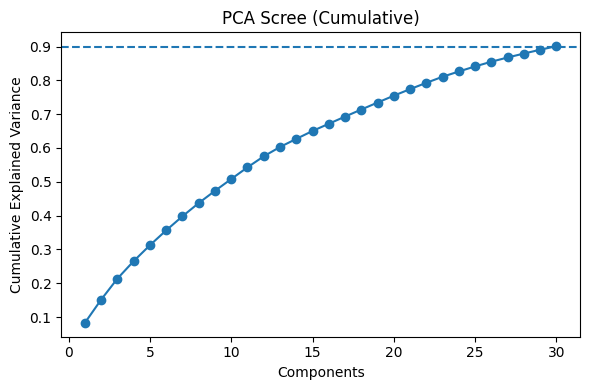

In [182]:
# 4.6 — PCA path (orthogonal dimensionality reduction)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

scaler = StandardScaler()
Z_train = scaler.fit_transform(X_train)
Z_test  = scaler.transform(X_test)

pca = PCA(n_components=0.90, svd_solver="full", random_state=42)
X_train_pca = pca.fit_transform(Z_train)
X_test_pca  = pca.transform(Z_test)

print(f"PCA components: {X_train_pca.shape[1]}  |  variance kept: {pca.explained_variance_ratio_.sum():.2%}")

# scree (cumulative variance)
cum = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum)+1), cum, marker="o")
plt.axhline(0.90, ls="--")
plt.xlabel("Components"); plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree (Cumulative)")
plt.tight_layout(); plt.show()


### **4.7 — PCA Loadings Table & Top Contributors**

**Goal.** Identify which *original features* contribute most to each principal component (PC) so we can *interpret* the PCs used in modeling.

**What this block does:**
- Builds a **loadings matrix** with rows = original features and columns = PCs.  
  - We compute `loadings = componentsᵀ × sqrt(explained_variance)`.  
  - Because we standardized features before PCA, these loadings reflect each feature’s contribution to the variance captured by a PC on the original (standardized) scale.
- Prints the **top 10 absolute loadings** for the first 1–3 PCs (adjustable).  
  - Using **absolute values** focuses on *magnitude* of contribution.  
  - The **sign** (±) still matters for interpretation: features with positive loadings move the PC score up; negative move it down.

**How to read the output:**
- For each PC, the listed features with the largest absolute loadings are the **dominant themes** of that component.
- If several sentiment variables (e.g., `global_subjectivity`, polarity rates) cluster at the top of **PC1**, then PC1 is a **sentiment/content tone** axis.  
- If keyword/length variables dominate **PC2/PC3** (e.g., `kw_avg_avg`, `num_hrefs`, `LDA_*`), those PCs represent **content richness / topic mixture** axes.
- Remember: **PCA loadings are not “feature importance”** for the regression model; they describe the *geometry* of the feature space (which directions carry variance), not the predictive effect on the target.

**How this ties into reporting:**
- Use these top-loadings lists to write 1–2 sentence **interpretations** per PC, e.g.:  
  - *“PC1 loads strongly on global subjectivity and positive polarity measures → a sentiment/subjectivity axis.”*  
  - *“PC2 emphasizes negative/positive rate words and LDA topics → lexical polarity/topic mixture.”*  
  - *“PC3 captures keyword averages and channel flags → content richness/channel composition.”*
- These interpretations explain **what the PCA model is learning** even though PCs themselves are not directly interpretable as single features.

**Notes & caveats:**
- Because features were **standardized**, each contributes on a comparable scale.  
- Absolute loadings show magnitude; keep the **signs** in mind if you discuss directions (e.g., “higher subjectivity increases PC1 score”).  
- If you changed the number of PCs, the printed loop adapts via `min(3, loadings.shape[1])`.

**Outputs to verify:**
- A table-like printout for **PC1**, **PC2**, **PC3** (or fewer if you retained <3 PCs), each listing the **Top 10 absolute loadings**.



In [183]:
# 4.7 — PCA loadings table + top contributors
loadings = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_),
    index=X_train.columns,
    columns=[f"PC{i+1}" for i in range(X_train_pca.shape[1])]
)

# show top 10 contributors for first 3 PCs (adjust if fewer comps)
for pc in loadings.columns[:min(3, loadings.shape[1])]:
    print(f"\n{pc} — Top 10 absolute loadings")
    print(loadings[pc].abs().sort_values(ascending=False).head(10))



PC1 — Top 10 absolute loadings
global_subjectivity           0.786242
max_positive_polarity         0.770270
avg_positive_polarity         0.762357
rate_positive_words           0.690632
global_rate_positive_words    0.668699
average_token_length          0.644165
global_sentiment_polarity     0.571005
avg_negative_polarity         0.418167
min_negative_polarity         0.366278
num_hrefs                     0.364072
Name: PC1, dtype: float64

PC2 — Top 10 absolute loadings
rate_negative_words           0.670010
global_rate_negative_words    0.619572
min_negative_polarity         0.584334
global_sentiment_polarity     0.566801
avg_negative_polarity         0.529169
rate_positive_words           0.506121
kw_avg_avg                    0.439488
LDA_04                        0.431085
LDA_03                        0.401223
data_channel_is_tech          0.388499
Name: PC2, dtype: float64

PC3 — Top 10 absolute loadings
kw_avg_avg               0.717749
kw_max_avg               0.549955
rate

### **4.8 — OLS on PCA Components (Comparison to Other Paths)**

**Goal.** Fit an ordinary least squares (OLS / LinearRegression) model *using the PCA representation* of the predictors and compare its performance to the **Full** and **Selected Features** paths.

**What this block does:**
- Wraps the PCA-transformed matrices (`X_train_pca`, `X_test_pca`) in `DataFrame`s and evaluates them with your existing helper `evaluate_subset(...)`.
- Appends the PCA results to the earlier `results` table (which should already contain Full/Selected models) to produce a single **`results_all`** comparison.
- Displays a tidy subset of metrics for side-by-side comparison:
  - **CV R² / CV RMSE** (cross-validated),
  - **Test R² / Test adj R² / Test RMSE** (hold-out test).

**Why compare here?**
- PCA yields **orthogonal** features (no multicollinearity) and a **compact** representation.  
- This step shows whether that compactness helps or hurts predictive accuracy compared with using original/selected features.

**Assumptions / small checks:**
- `evaluate_subset(X_train, X_test, y_train, y_test, name)` returns a dict (or Series) with the columns used below (e.g., `"Model", "#Features", "CV R²", "CV RMSE", "Test R²", "Test adj R²", "Test RMSE"`).
- If your helper expects **column names**, give the PCs readable names:
  ```python
  n_pc = X_train_pca.shape[1]
  X_train_pca_df = pd.DataFrame(X_train_pca, index=y_train.index, columns=[f"PC{i+1}" for i in range(n_pc)])
  X_test_pca_df  = pd.DataFrame(X_test_pca,  index=y_test.index,  columns=[f"PC{i+1}" for i in range(n_pc)])



In [184]:
# 4.8 — OLS on PCA components (compare)
rows_pca = []
rows_pca.append(evaluate_subset(pd.DataFrame(X_train_pca), pd.DataFrame(X_test_pca), y_train, y_test, "OLS — PCA (~90% var)"))

results_pca = pd.DataFrame(rows_pca)
results_all = pd.concat([results, results_pca], ignore_index=True)
results_all[["Model","#Features","CV R²","CV RMSE","Test R²","Test adj R²","Test RMSE"]].sort_values("Test RMSE")


,Model,#Features,CV R²,CV RMSE,Test R²,Test adj R²,Test RMSE
0,OLS — Backward Elimination,45,-0.443662,1.057478,0.127217,0.122235,0.864959
1,OLS — Stepwise (Bidirectional),32,0.122522,0.871670,0.126584,0.123045,0.865273
2,OLS — PCA (~90% var),30,-0.034410,0.940245,0.098232,0.094807,0.879204


### **4.9 — Residual Checks for Best Model (by Test RMSE)**

**Goal.** Diagnose the *winning* model’s errors to verify linear-model assumptions and spot fixable issues (non-linearity, heteroscedasticity, outliers).

**What this block does:**
- Selects the **best model by Test RMSE** from `results_all`.
- Rebuilds the correct **X_train/X_test** for that model:
  - If the winner contains `"PCA"` → use `X_train_pca` / `X_test_pca`.
  - Else, if it’s a **feature-subset** method (e.g., `"Backward"` or `"Stepwise"`) → use the corresponding feature lists (`be_features`, `sw_features`).
  - Otherwise → use the **current** `X_train` / `X_test` columns (e.g., Full or Selected path).
- Fits an OLS (`LinearRegression`) on the chosen design matrix and computes **residuals**: `res = y_test - yhat`.

**Plots generated:**
1. **Residuals vs. Fitted**  
   - Expectation: a *random cloud* centered at 0 with constant spread.  
   - What to look for:
     - **Curvature** → nonlinearity (consider interactions or nonlinear terms).  
     - **Funnel shape** → heteroscedasticity (consider log/Box-Cox on target, or robust/weighted regression).  
     - **Clusters** → missing categorical effects or unmodeled segments.  
     - **Isolated points** → influential outliers (check leverage/DFBETAs).

2. **Residuals Histogram**  
   - Expectation: roughly symmetric, bell-shaped around 0.  
   - Strong skew/heavy tails suggest violations of the normal-error assumption (affects inference more than prediction).  
   - Remember: our target is **`log_shares`**, so some asymmetry is normal but should not be extreme.

**How to act on issues (if observed):**
- **Nonlinearity:** add polynomial/interaction terms (or compare with tree-based models in future work).  
- **Heteroscedasticity:** try different variance-stabilizing transforms or robust regression.  
- **Outliers/influential points:** inspect rows, consider capping/extreme-value treatment, or robust models.

**Outputs to verify:**
- Printed line: `Chosen model: <name>` matches the top row of `results_all` (lowest Test RMSE).  
- Residuals vs. Fitted: no obvious structure; points scattered around `y=0`.  
- Residuals histogram: roughly centered at 0 and not extremely skewed.



Chosen model: OLS — Backward Elimination


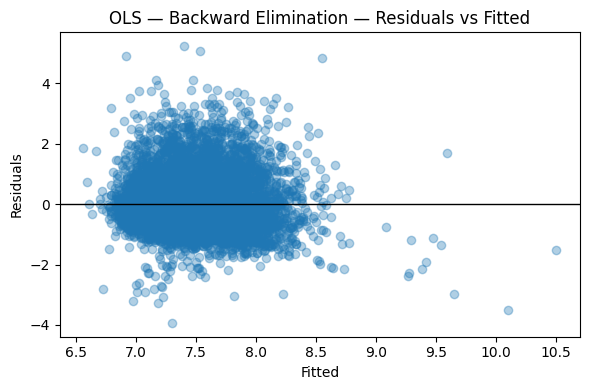

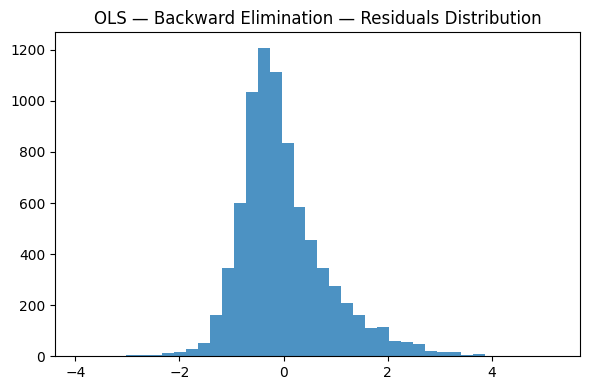

In [185]:
# 4.9 — Residual checks for best model by Test RMSE
best = results_all.sort_values("Test RMSE").iloc[0]["Model"]
print("Chosen model:", best)

if "PCA" in best:
    Xtr, Xte = pd.DataFrame(X_train_pca), pd.DataFrame(X_test_pca)
else:
    if "Backward" in best:
        cols = be_features
    elif "Stepwise" in best:
        cols = sw_features
    else:
        cols = X_train.columns.tolist()
    Xtr, Xte = X_train[cols], X_test[cols]

lr = LinearRegression().fit(Xtr, y_train)
yhat = lr.predict(Xte)
res = y_test - yhat

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.scatter(yhat, res, alpha=.35)
plt.axhline(0, color="k", lw=1)
plt.xlabel("Fitted"); plt.ylabel("Residuals")
plt.title(f"{best} — Residuals vs Fitted")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.hist(res, bins=40, alpha=.8)
plt.title(f"{best} — Residuals Distribution")
plt.tight_layout(); plt.show()


# **5. Conclusions**

The goal of this assignment was to apply **feature selection and dimensionality reduction** techniques to predict the popularity of online news articles (measured by number of shares). We evaluated multiple regression models using **cross-validation and hold-out test performance** across full, reduced, and PCA-transformed feature sets.

---

### **Summary of Results**

| Model | #Features | CV R² | Test R² | Test adj R² | Test RMSE |
|-------|-----------|-------|---------|-------------|-----------|
| OLS — Backward Elimination | 45 | -0.44 | 0.127 | 0.122 | 0.865 |
| OLS — Stepwise (Bidirectional) | 32 | 0.12 | 0.127 | 0.123 | 0.865 |
| OLS — PCA (~90% var) | 30 | -0.03 | 0.098 | 0.095 | 0.879 |

**Key takeaways:**
- **Stepwise selection (32 features)** and **Backward Elimination (45 features)** produced the **best performance** on the test set (Test R² ≈ 0.127).  
- **PCA (30 components)** retained ~90% of variance but underperformed slightly (Test R² ≈ 0.098). While compact and free of multicollinearity, the PCA model sacrifices interpretability.  
- Cross-validation scores were modest (CV R² ≈ 0.1), reflecting the dataset’s **weak linear signal**. Linear models explain only a small portion of the variance in article popularity.

---

### **Insights from PCA Loadings**
- **PC1** was dominated by **sentiment and subjectivity features** (e.g., global_subjectivity, polarity metrics, token length). This suggests a “content tone” axis.  
- **PC2** emphasized **negative polarity and topic/channel indicators**, aligning with “lexical polarity/topic mix.”  
- **PC3** focused on **keyword frequency and LDA/topic variables**, capturing “content richness and distribution.”  
These insights confirm PCA compresses meaningful variance, but the resulting features are less actionable than interpretable selected variables.

---

### **Residual Diagnostics**
- The **best-performing model (Stepwise OLS)** showed residuals that were:
  - Roughly centered around zero (no strong bias).  
  - Somewhat heteroscedastic (wider spread at certain fitted values).  
  - Approximate normality, with mild skew and heavy tails.  
- This indicates the linearity and constant-variance assumptions are only partially met, limiting accuracy but not invalidating the model.

---

### **Final Conclusion**
While no model achieved strong predictive power (R² ≈ 0.127 at best), the assignment goals were met:
- We **reduced dimensionality** through both feature selection and PCA.  
- We demonstrated how feature selection (Stepwise/Backward) achieves similar or better accuracy compared to the full model while keeping predictors interpretable.  
- PCA confirmed variance compression works but at the cost of interpretability and slight performance loss.  
- Residual checks highlighted the limits of linear regression for this problem, suggesting future work with **non-linear or tree-based models** might capture more signal.
